In [ ]:
# Bluesky Brand Analytics: Wired vs The Verge

import json
import time
import re
import warnings
from datetime import datetime, timezone
from pathlib import Path
from getpass import getpass
from collections import Counter
from itertools import combinations
from typing import cast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import networkx as nx

from nltk.corpus import stopwords
from textblob import Word
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from atproto import Client
from atproto_client.models.app.bsky.feed.search_posts import Params as SearchParams
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from wordcloud import WordCloud
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROC_DIR = PROJECT_ROOT / "data" / "processed"
TAB_DIR = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data: {RAW_DIR}")
print(f"Processed data: {PROC_DIR}")
print(f"Tables: {TAB_DIR}")
print(f"Figures: {FIG_DIR}")

Project root: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2
Raw data: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/raw
Processed data: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/processed
Tables: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/outputs/tables
Figures: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/outputs/figures


In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving raw data to: {RAW_DIR}")

Saving raw data to: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/raw


## 1. Data Collection

In [4]:
# BSKY_HANDLE = input("Bluesky handle (e.g. yourname.bsky.social): ").strip()
# BSKY_APP_PASSWORD = getpass("Bluesky App Password (xxxx-xxxx-xxxx-xxxx): ")

BSKY_HANDLE = "shreyuu-dev.bsky.social"
BSKY_APP_PASSWORD = "osip-pbxt-xnfz-52kf"
BASE_URL = "https://bsky.social/xrpc"

client = Client(base_url=BASE_URL)
profile = client.login(BSKY_HANDLE, BSKY_APP_PASSWORD)
print(f"Logged in as: {profile.display_name} (@{profile.handle})")

Logged in as:  (@shreyuu-dev.bsky.social)


In [5]:
def extract_post_record(post) -> dict:
    """Flatten a Bluesky post object to a dict suitable for a pandas row."""
    record = post.record
    author = post.author
    return {
        "uri": post.uri,
        "cid": post.cid,
        "author_did": author.did,
        "author_handle": author.handle,
        "author_display_name": getattr(author, "display_name", None),
        "text": getattr(record, "text", ""),
        "created_at": getattr(record, "created_at", None),
        "indexed_at": getattr(post, "indexed_at", None),
        "langs": ",".join(getattr(record, "langs", []) or []),
        "like_count": getattr(post, "like_count", 0) or 0,
        "repost_count": getattr(post, "repost_count", 0) or 0,
        "reply_count": getattr(post, "reply_count", 0) or 0,
        "quote_count": getattr(post, "quote_count", 0) or 0,
        "is_reply": bool(getattr(record, "reply", None)),
        "embed_type": (
            type(post.embed).__name__ if getattr(post, "embed", None) else None
        ),
    }

In [6]:
def paginated_search(query, max_posts=1000, lang="en", sort="latest",
                     sleep_seconds=0.5, verbose=True):
    """Repeatedly call Bluesky's search_posts endpoint until max_posts retrieved
    or no more results are available."""
    posts = []
    cursor = None
    page = 0
    while len(posts) < max_posts:
        params = SearchParams(
            q=query,
            limit=min(100, max_posts - len(posts)),
            cursor=cursor,
            lang=lang,
            sort=sort,
        )
        try:
            response = client.app.bsky.feed.search_posts(params)
        except Exception as e:
            print(f"  [warn] search call failed on page {page}: {e}")
            break

        page_posts = response.posts
        if not page_posts:
            break

        for post in page_posts:
            try:
                posts.append(extract_post_record(post))
            except Exception as e:
                print(f"  [warn] could not extract a post: {e}")

        cursor = response.cursor
        page += 1
        if verbose:
            print(f"  page {page:>3}: total posts so far = {len(posts):>4}")
        if cursor is None:
            break
        time.sleep(sleep_seconds)
    return posts

In [7]:
def fetch_profiles_batch(dids, batch_size=25, sleep_seconds=0.5):
    """Resolve author DIDs to full profile objects (followers, follows, bio)."""
    profiles = []
    unique_dids = list(dict.fromkeys(dids))
    for i in range(0, len(unique_dids), batch_size):
        batch = unique_dids[i : i + batch_size]
        try:
            response = client.app.bsky.actor.get_profiles({"actors": batch})
        except Exception as e:
            print(f"  [warn] profile batch {i // batch_size} failed: {e}")
            continue

        for p in response.profiles:
            profiles.append({
                "did": p.did,
                "handle": p.handle,
                "display_name": getattr(p, "display_name", None),
                "description": getattr(p, "description", None),
                "followers_count": getattr(p, "followers_count", 0) or 0,
                "follows_count": getattr(p, "follows_count", 0) or 0,
                "posts_count": getattr(p, "posts_count", 0) or 0,
                "created_at": getattr(p, "created_at", None),
                "indexed_at": getattr(p, "indexed_at", None),
                "verified": getattr(p, "verification", None) is not None,
            })
        time.sleep(sleep_seconds)
    return profiles

In [8]:
BRAND_QUERIES = {
    "wired": [
        "wired.com",        # domain
        "@wired.com",       # handle
        '"wired magazine"',     # phrase query
        '"on wired"',
        '"via wired"',
        '"wired says"',      # topical compound to capture article-referencing posts
        '"wired reports"',
        '"wired story"',
        '"wired article"',
        '"wired piece"',
    ],
    "theverge": [
        "theverge.com",     # domain
        "@theverge.com",        # handle
        '"the verge"',      # phrase query
        '"verge says"',     # topical compound to capture article-referencing posts
        '"verge reports"',
        '"verge story"',
        '"verge article"',
        '"verge review"',
        '"according to the verge"',
    ],
}

POSTS_PER_QUERY = 500
TARGET_PER_BRAND = 2500   # collecting generously; cleaning will trim

In [9]:
def collect_brand_posts(brand, queries):
    """Run every query for a brand, deduplicate by URI, return as DataFrame."""
    print(f"\n=== Collecting posts for: {brand} ===")
    all_posts = []
    for q in queries:
        print(f"  Query: {q!r}")
        posts = paginated_search(query=q, max_posts=POSTS_PER_QUERY)
        for p in posts:
            p["query"] = q
        all_posts.extend(posts)
        print(f"   -> {len(posts)} posts retrieved for this query")

    df = pd.DataFrame(all_posts)
    if df.empty:
        return df

    before = len(df)
    df = df.drop_duplicates(subset="uri", keep="first").reset_index(drop=True)
    print(f"  Deduplication: {before} -> {len(df)} unique posts")

    if len(df) > TARGET_PER_BRAND:
        df = df.head(TARGET_PER_BRAND).reset_index(drop=True)

    df["brand"] = brand
    return df

In [80]:
wired_df = collect_brand_posts("wired", BRAND_QUERIES["wired"])
print(f"\nWired total: {len(wired_df)} unique posts, {wired_df['author_did'].nunique()} unique authors")
wired_df[["author_handle", "text", "like_count", "repost_count"]].head(5)


=== Collecting posts for: wired ===
  Query: 'wired.com'
  page   1: total posts so far =   99
  page   2: total posts so far =  197
  page   3: total posts so far =  297
  page   4: total posts so far =  394
  page   5: total posts so far =  494
  page   6: total posts so far =  500
   -> 500 posts retrieved for this query
  Query: '@wired.com'
  page   1: total posts so far =   99
  page   2: total posts so far =  197
  page   3: total posts so far =  297
  page   4: total posts so far =  394
  page   5: total posts so far =  492
  page   6: total posts so far =  500
   -> 500 posts retrieved for this query
  Query: '"wired magazine"'
  page   1: total posts so far =   97
  page   2: total posts so far =  195
  page   3: total posts so far =  292
  page   4: total posts so far =  387
  page   5: total posts so far =  484
  page   6: total posts so far =  500
   -> 500 posts retrieved for this query
  Query: '"on wired"'
  page   1: total posts so far =   96
  page   2: total posts s

,author_handle,text,like_count,repost_count
0,upscrolled.bsky.social,"""Would you hang a picture of your perpetrator ...",4,1
1,longtail-news.bsky.social,"Feed: ""Ars Technica - All content""\nBy: Boone ...",0,0
2,dustandroad.bsky.social,‘It’s Undignified’: Hundreds of Workers Traini...,0,0
3,remalone.bsky.social,Concerned about Trump seizing election records...,2,3
4,toddcorley.bsky.social,It is VERY telling when corporations like @pro...,0,0


In [149]:
def highlight_wired(val):
    """Visual sanity-check that retrieved posts are actually about Wired."""
    pattern = r'(wired\.com|@wired\.com|wired\s+(magazine|says|reports|story|article|piece))'
    return re.sub(pattern, r'<mark>\1</mark>', str(val), flags=re.IGNORECASE)

wired_df['text'].head(15).to_frame().style.format(highlight_wired)

,text
0,"""Would you hang a picture of your perpetrator in the living room?"" Full @wired.com interview here 👉 www.wired.com/story/the-bi..."
1,"Feed: ""Ars Technica - All content"" By: Boone Ashworth, wired.com on Wednesday, April 29, 2026"
2,"‘It’s Undignified’: Hundreds of Workers Training Meta’s #AI Could Be Laid Off. More than 700 people working for a #Meta contractor in Ireland are at risk of losing their jobs, documents show. Via @wired.com"
3,Concerned about Trump seizing election records? You should be. Nobody left in the Voting Rights section at DOJ to care. Great work from @wired.com : www.wired.com/story/the-ju...
4,It is VERY telling when corporations like @proton take actions such as this. As if they will get away from all their lies. @wired.com should do a story on how @PROTON is actually compromised and NOT living up to what they promise users!!!
5,"GETTING HANDSY: ""A robot’s claw hurtles toward a light bulb. I wince, waiting for the crunch. The bulb rolls away. After a few nips, the bulb is in its grasp. In 10+ years writing about robots I've never seen one move so naturally."" @willknight.bsky.social on @wired.com www.wired.com/story/when-r..."
6,"Shut up!! Shut up about goblins!! New in @wired.com: 'Never talk about goblins, gremlins, raccoons, trolls, ogres, pigeons, or other animals or creatures unless it is absolutely and unambiguously relevant' www.wired.com/story/openai..."
7,“AI agents may soon be buying your stuff for you. The FIDO Alliance has teamed up with Google and Mastercard to try to ensure that shopping in the near future isn't a complete disaster.” www.wired.com/story/the-ra... @wired.com
8,@eff.org @wired.com @youranoncentral.bsky.social @indivisible.org @teslatakedown.com @housedemocrats.bsky.social @dscc.bsky.social @meidastouch.com @briantylercohen.bsky.social
9,#EpsteinClass @eff.org @wired.com @indivisible.org @teslatakedown.com @youranoncentral.bsky.social @votersoftomorrow.org


In [150]:
verge_df = collect_brand_posts("theverge", BRAND_QUERIES["theverge"])
print(f"\nThe Verge total: {len(verge_df)} unique posts, {verge_df['author_did'].nunique()} unique authors")
verge_df[["author_handle", "text", "like_count", "repost_count"]].head(5)


=== Collecting posts for: theverge ===
  Query: 'theverge.com'
  page   1: total posts so far =   99
  page   2: total posts so far =  198
  page   3: total posts so far =  297
  page   4: total posts so far =  395
  page   5: total posts so far =  491
  page   6: total posts so far =  498
  page   7: total posts so far =  500
   -> 500 posts retrieved for this query
  Query: '@theverge.com'
  page   1: total posts so far =   98
  page   2: total posts so far =  197
  page   3: total posts so far =  296
  page   4: total posts so far =  391
  page   5: total posts so far =  488
  page   6: total posts so far =  500
   -> 500 posts retrieved for this query
  Query: '"the verge"'
  page   1: total posts so far =  100
  page   2: total posts so far =  199
  page   3: total posts so far =  298
  page   4: total posts so far =  398
  page   5: total posts so far =  496
  page   6: total posts so far =  500
   -> 500 posts retrieved for this query
  Query: '"verge says"'
  page   1: total p

,author_handle,text,like_count,repost_count
0,kcurry.bsky.social,google search queries hit an all-time high in ...,0,0
1,heflin.bsky.social,I really need to free up some subscription mon...,0,0
2,kcurry.bsky.social,xbox email addresses coming for xbox employees...,0,0
3,idlesloth.bsky.social,Mojang employees will also be given an mojangc...,1,0
4,forensicgarlic.bsky.social,I already know what the 'Brendan Carr is a dum...,0,0


In [151]:
def highlight_verge(val):
    pattern = r'(theverge\.com|@theverge\.com|the\s+verge|verge\s+(says|reports|story|article|review))'
    return re.sub(pattern, r'<mark>\1</mark>', str(val), flags=re.IGNORECASE)

verge_df['text'].head(15).to_frame().style.format(highlight_verge)

,text
0,google search queries hit an all-time high in q1 2026 - probably has something to do with all the ai chatbots we're using these days. {https://theverge.com} https://www.theverge.com/tech/920815/google-alphabet-q1-2026-earnings-sundar-pichai
1,I really need to free up some subscription money for @theverge.com. @lopatto.bsky.social's reporting alone would be worth it.
2,"xbox email addresses coming for xbox employees - because ""we are xbox"" now apparently. {https://theverge.com/rss/index.xml} https://www.theverge.com/report/920525/microsoft-xbox-email-address-change"
3,"Mojang employees will also be given an mojangcom email address, and both Xbox and Mojang employees will still retain their microsoftcom email aliases. The change is being made as part of “strengthening the Xbox identity inside and outside of Microsoft,” theverge.com/report/92052..."
4,I already know what the 'Brendan Carr is a dummy ' segment of the @theverge.com podcast is going to be about...
5,@joncooper-us.bsky.social @andrewjweinstein.com @propublica.org @theverge.com @cookpolitical.com @urocklive1.bsky.social @bluestormcomin1.bsky.social @cwebbonline.com @teapainusa.bsky.social @meidastouch.com @georgetakei.bsky.social @gtconway.bsky.social @aclu.org @patrioticmillionaires.org
6,"@theverge.com do a blog on arena sideline tech: clocks, scoreboards, buzzers"
7,Is it time for America's favourite podcast within a podcast???? @theverge.com
8,elon musk testifies in trial against openai co-founders. this is getting real. {theverge.com} https://www.theverge.com/ai-artificial-intelligence/917052/elon-musk-takes-stand-trial-openai-sam-altman
9,"Can't wait until this week's episode of ""Brendan Carr is a Dummy"" @reckless.bsky.social @davidpierce.xyz @theverge.com"


In [152]:
wired_path = RAW_DIR / "wired_posts_raw.csv"
verge_path = RAW_DIR / "theverge_posts_raw.csv"

wired_df.to_csv(wired_path, index=False)
verge_df.to_csv(verge_path, index=False)

print(f"Saved {len(wired_df)} Wired posts -> {wired_path}")
print(f"Saved {len(verge_df)} Verge posts -> {verge_path}")

Saved 2500 Wired posts -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/raw/wired_posts_raw.csv
Saved 1946 Verge posts -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/raw/theverge_posts_raw.csv


In [153]:
print("Fetching profiles for Wired authors...")
wired_dids = wired_df["author_did"].dropna().unique().tolist()
wired_profiles = pd.DataFrame(fetch_profiles_batch(wired_dids))
print(f"  -> {len(wired_profiles)} profiles fetched")

print("\nFetching profiles for The Verge authors...")
verge_dids = verge_df["author_did"].dropna().unique().tolist()
verge_profiles = pd.DataFrame(fetch_profiles_batch(verge_dids))
print(f"  -> {len(verge_profiles)} profiles fetched")

Fetching profiles for Wired authors...
  -> 1597 profiles fetched

Fetching profiles for The Verge authors...
  -> 1527 profiles fetched


In [154]:
wired_profiles_path = RAW_DIR / "wired_profiles_raw.csv"
verge_profiles_path = RAW_DIR / "theverge_profiles_raw.csv"

wired_profiles.to_csv(wired_profiles_path, index=False)
verge_profiles.to_csv(verge_profiles_path, index=False)

print(f"Saved {len(wired_profiles)} Wired profiles")
print(f"Saved {len(verge_profiles)} Verge profiles")

Saved 1597 Wired profiles
Saved 1527 Verge profiles


In [155]:
def date_range(df):
    if df.empty or "created_at" not in df.columns:
        return ("n/a", "n/a")
    s = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
    return (str(s.min()), str(s.max()))

metadata = {
    "collection_run_at": datetime.now(timezone.utc).isoformat(),
    "collected_by_handle": BSKY_HANDLE,
    "language_filter": "en",
    "sort_order": "latest",
    "geographic_scope": "global (Bluesky search does not expose location filtering)",
    "brand_pair_rationale": (
        "Wired vs The Verge selected as direct competitors in technology "
        "journalism with distinct editorial positioning (long-form/culture vs "
        "product-review/news-cycle). Brand pair was changed from an initial "
        "Hugging Face vs Replicate selection after pilot data showed that "
        "'replicate' as a common English verb produced unresolvable lexical "
        "collision under any reasonable precision/recall trade-off."
    ),
    "brands": {
        "wired": {
            "queries": BRAND_QUERIES["wired"],
            "n_posts": int(len(wired_df)),
            "n_unique_users": int(wired_df["author_did"].nunique()) if not wired_df.empty else 0,
            "date_range": date_range(wired_df),
            "n_profiles_fetched": int(len(wired_profiles)),
        },
        "theverge": {
            "queries": BRAND_QUERIES["theverge"],
            "n_posts": int(len(verge_df)),
            "n_unique_users": int(verge_df["author_did"].nunique()) if not verge_df.empty else 0,
            "date_range": date_range(verge_df),
            "n_profiles_fetched": int(len(verge_profiles)),
        },
    },
}

meta_path = RAW_DIR / "collection_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))

{
  "collection_run_at": "2026-04-30T10:03:23.160344+00:00",
  "collected_by_handle": "shreyuu-dev.bsky.social",
  "language_filter": "en",
  "sort_order": "latest",
  "geographic_scope": "global (Bluesky search does not expose location filtering)",
  "brand_pair_rationale": "Wired vs The Verge selected as direct competitors in technology journalism with distinct editorial positioning (long-form/culture vs product-review/news-cycle). Brand pair was changed from an initial Hugging Face vs Replicate selection after pilot data showed that 'replicate' as a common English verb produced unresolvable lexical collision under any reasonable precision/recall trade-off.",
  "brands": {
    "wired": {
      "queries": [
        "wired.com",
        "@wired.com",
        "\"wired magazine\"",
        "\"on wired\"",
        "\"via wired\"",
        "\"wired says\"",
        "\"wired reports\"",
        "\"wired story\"",
        "\"wired article\"",
        "\"wired piece\""
      ],
      "n_posts

In [156]:
def quick_summary(df, name):
    print(f"--- {name} ---")
    if df.empty:
        print(" (empty)")
        return
    print(f"  Total posts:     {len(df)}")
    print(f"  Unique authors:  {df['author_did'].nunique()}")
    print(f"  Date range:      {date_range(df)}")
    print(f"  Mean likes/post: {df['like_count'].mean():.2f}")
    print(f"  Mean reposts/post: {df['repost_count'].mean():.2f}")
    print(f"  Reply share:     {df['is_reply'].mean():.1%}")

quick_summary(wired_df, "Wired")
print()
quick_summary(verge_df, "The Verge")

--- Wired ---
  Total posts:     2500
  Unique authors:  1597
  Date range:      ('2023-09-21 16:45:42.951000+00:00', '2026-04-30 08:36:26.322000+00:00')
  Mean likes/post: 18.93
  Mean reposts/post: 5.60
  Reply share:     29.1%

--- The Verge ---
  Total posts:     1946
  Unique authors:  1527
  Date range:      ('2023-07-03 17:39:11.855000+00:00', '2026-04-30 09:44:04.532000+00:00')
  Mean likes/post: 12.08
  Mean reposts/post: 2.85
  Reply share:     35.9%


## 2. Data Cleaning & Pre-processing

In [230]:
# Data Cleaning and Preprocessing

for pkg in ["stopwords", "wordnet", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(
            f"corpora/{pkg}" if pkg != "punkt" and pkg != "punkt_tab"
            else f"tokenizers/{pkg}"
        )
    except LookupError:
        nltk.download(pkg, quiet=True)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR  = PROJECT_ROOT / "data" / "raw"
PROC_DIR = PROJECT_ROOT / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading raw data from   : {RAW_DIR}")
print(f"Writing processed data to: {PROC_DIR}")

Reading raw data from   : /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/raw
Writing processed data to: /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/processed


In [231]:
wired_posts_raw = pd.read_csv(RAW_DIR / "wired_posts_raw.csv")
verge_posts_raw = pd.read_csv(RAW_DIR / "theverge_posts_raw.csv")

wired_profiles_raw = pd.read_csv(RAW_DIR / "wired_profiles_raw.csv")
verge_profiles_raw = pd.read_csv(RAW_DIR / "theverge_profiles_raw.csv")

print(f"Wired posts (raw)        : {len(wired_posts_raw):>5}")
print(f"The Verge posts (raw)    : {len(verge_posts_raw):>5}")
print(f"Wired profiles (raw)     : {len(wired_profiles_raw):>5}")
print(f"The Verge profiles (raw) : {len(verge_profiles_raw):>5}")

Wired posts (raw)        :  2500
The Verge posts (raw)    :  1946
Wired profiles (raw)     :  1597
The Verge profiles (raw) :  1527


In [232]:
URL_RE     = re.compile(r"https?://\S+|www\.\S+|\S+\.(?:com|co|io|net|org|ai|app|dev|gg)/\S*", re.IGNORECASE)
MENTION_RE = re.compile(r"@[\w.-]+")
HASHTAG_RE = re.compile(r"#\w+")
DOMAIN_RE  = re.compile(r"(?:https?://)?(?:www\.)?([\w-]+(?:\.[\w-]+)+)", re.IGNORECASE)

def extract_features(text: str) -> dict:
    if not isinstance(text, str):
        return {"urls": [], "mentions": [], "hashtags": [], "domains": []}
    urls     = URL_RE.findall(text)
    mentions = MENTION_RE.findall(text)
    hashtags = [h.lower() for h in HASHTAG_RE.findall(text)]
    domains  = [m.group(1).lower() for m in DOMAIN_RE.finditer(text) if m.group(1)]
    domains  = [d for d in domains if d.count(".") >= 1 and len(d) >= 4]
    return {"urls": urls, "mentions": mentions, "hashtags": hashtags, "domains": domains}

def add_extracted_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = df["text"].apply(extract_features).apply(pd.Series)
    df = df.copy()
    df["urls"]       = feats["urls"].apply(lambda xs: ";".join(xs))
    df["mentions"]   = feats["mentions"].apply(lambda xs: ";".join(xs))
    df["hashtags"]   = feats["hashtags"].apply(lambda xs: ";".join(xs))
    df["domains"]    = feats["domains"].apply(lambda xs: ";".join(xs))
    df["n_urls"]     = feats["urls"].apply(len)
    df["n_mentions"] = feats["mentions"].apply(len)
    df["n_hashtags"] = feats["hashtags"].apply(len)
    return df

wired_posts = add_extracted_features(wired_posts_raw)
verge_posts = add_extracted_features(verge_posts_raw)
print("Extracted URL/mention/hashtag/domain features.")

Extracted URL/mention/hashtag/domain features.


In [233]:
# Brand-relevance filter applied at the cleaning stage rather than collection, because the precision first phrase queries already enforced strong relevance at search time. The remaining concern is the English idiom "on the verge of"
# (also "verge of collapse", "verge of tears") which the phrase query "the verge" admits as false positives. We also do a defensive pass on Wired to catch any "fully wired" / "wired in" / "hard-wired" adjective uses.

# Logic for each brand:
#   Path 1: explicit domain reference        -> always relevant
#   Path 2: explicit handle reference        -> always relevant
#   Path 3: brand name + journalism anchor   -> relevant
#   Otherwise: reject as adjective/idiom usage

# Domain / handle anchors
WIRED_DOMAIN = re.compile(r"wired\.com|@wired\.com|wired\.co\.uk", flags=re.IGNORECASE)
VERGE_DOMAIN = re.compile(r"theverge\.com|@theverge\.com",          flags=re.IGNORECASE)

# Journalism / publication-context anchors. Co-occurrence with the brand name strongly implies the publication-as-brand reading vs the adjective/idiom.
PUB_ANCHORS = re.compile(
    r"\b(article|piece|story|stories|published|publish|publishes|"
    r"reports?|reported|reporting|writes?|wrote|writing|writer|"
    r"journalist|reviews?|reviewed|reviewer|interview|interviewed|"
    r"covers?|covered|coverage|feature|featured|column|columnist|"
    r"editorial|editor|magazine|publication|byline|headline|"
    r"investigation|investigates?|investigated|"
    r"podcast|newsletter|subscribe|subscription|paywall|"
    r"according\s+to|via)\b",
    flags=re.IGNORECASE,
)

# Capitalised proper-noun patterns. Case-sensitive "wired" lowercase is the adjective; "Wired" capitalised is the brand. "verge" lowercase + "the" can be either; capitalised "Verge" is more reliable.
WIRED_PROPER     = re.compile(r"\bWired\b")
VERGE_PROPER     = re.compile(r"\bVerge\b|\bThe Verge\b")
THE_VERGE_LOWER  = re.compile(r"\bthe verge\b", flags=re.IGNORECASE)

def is_brand_relevant_wired(text: str) -> bool:
    if not isinstance(text, str) or not text.strip():
        return False
    # Path 1+2: domain or handle reference
    if WIRED_DOMAIN.search(text):
        return True
    # Path 3: capitalised "Wired" + a journalism anchor
    if WIRED_PROPER.search(text) and PUB_ANCHORS.search(text):
        return True
    return False

def is_brand_relevant_verge(text: str) -> bool:
    if not isinstance(text, str) or not text.strip():
        return False
    # Path 1+2: domain or handle reference (the strongest signal)
    if VERGE_DOMAIN.search(text):
        return True
    # Path 3: capitalised "Verge" + journalism anchor
    if VERGE_PROPER.search(text) and PUB_ANCHORS.search(text):
        return True
    # Path 4: lowercase "the verge" + journalism anchor (catches casual posts)
    if THE_VERGE_LOWER.search(text) and PUB_ANCHORS.search(text):
        return True
    return False

# Apply
wired_before = len(wired_posts)
wired_posts  = wired_posts[wired_posts["text"].apply(is_brand_relevant_wired)].reset_index(drop=True)
print(f"Wired brand-relevance     : {wired_before} -> {len(wired_posts)} posts retained")

verge_before = len(verge_posts)
verge_posts  = verge_posts[verge_posts["text"].apply(is_brand_relevant_verge)].reset_index(drop=True)
print(f"The Verge brand-relevance : {verge_before} -> {len(verge_posts)} posts retained")

Wired brand-relevance     : 2500 -> 1758 posts retained
The Verge brand-relevance : 1946 -> 1244 posts retained


In [234]:
# Stopword set: NLTK English + custom additions for Bluesky/journalism discourse
# 'wired', 'verge' etc. are added to a separate set so we can remove them only for topic modelling (where they would dominate as the topic), not for general keyword frequency or sentiment.

BASE_STOPWORDS = set(stopwords.words("english"))

CUSTOM_STOPWORDS = {
    # generic web/Bluesky noise
    "rt", "amp", "via", "http", "https", "com", "www", "html",
    "bsky", "app", "post", "thread", "skeet",
    # filler
    "like", "get", "got", "go", "going", "use", "using", "used",
    "one", "two", "would", "could", "also", "really", "much", "many",
    "see", "say", "said", "make", "made", "take", "took",
    "want", "wanted", "even", "still", "well", "way", "things", "thing",
    "today", "yesterday", "tomorrow", "now", "ll", "ve", "re",
}

# Brand tokens only stripped for topic-modelling text variant
BRAND_STOPWORDS = {
    "wired", "wiredcom", "wiredmag",
    "verge", "theverge", "thevergecom",
}

ALL_STOPWORDS          = BASE_STOPWORDS | CUSTOM_STOPWORDS
ALL_STOPWORDS_NO_BRAND = ALL_STOPWORDS  | BRAND_STOPWORDS

def clean_text(text: str) -> str:
    """
    Course-aligned aggressive clean (mirrors Week 7's cleanText):
      - strip URLs / mentions / hashtags (we already extracted them)
      - lowercase
      - remove punctuation, digits, single letters
      - normalise accented characters
    """
    if not isinstance(text, str):
        return ""
    # Bluesky-specific strips first
    text = URL_RE.sub(" ",     text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    # Course-style cleaning
    text = re.sub(r"[^\w\s]", " ", text)       # remove punctuation
    text = re.sub(r"\d+", " ", text)           # remove digits
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)  # remove single letters
    text = text.lower()
    text = re.sub(u"[àáâãäå]", "a", text)
    text = re.sub(u"[èéêë]",   "e", text)
    text = re.sub(u"[ìíîï]",   "i", text)
    text = re.sub(u"[òóôõö]",  "o", text)
    text = re.sub(u"[ùúûü]",   "u", text)
    text = re.sub(u"[ț]",      "t", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_stopwords_lemmatize(text: str, stopword_set: set) -> str:
    """Token-level pass: drop stopwords and lemmatize what survives."""
    if not text:
        return ""
    tokens = [
        Word(tok).lemmatize()
        for tok in text.split()
        if tok not in stopword_set and len(tok) > 2
    ]
    return " ".join(tokens)

def light_clean_for_sentiment(text: str) -> str:
    """
    Lighter clean for VADER / TextBlob sentiment - keeps casing, punctuation,
    emoji-style cues, but strips URLs/mentions/hashtags as those don't carry
    affect and inflate the input length.
    """
    if not isinstance(text, str):
        return ""
    text = URL_RE.sub(" ",     text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [235]:
def clean_posts(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.rename(columns={"text": "text_raw"})

    # Light clean for sentiment scoring
    df["text_for_sentiment"] = df["text_raw"].apply(light_clean_for_sentiment)

    # Aggressive clean for keyword/frequency analysis
    df["text_clean_stage1"] = df["text_raw"].apply(clean_text)
    df["text_clean"] = df["text_clean_stage1"].apply(
        lambda t: remove_stopwords_lemmatize(t, ALL_STOPWORDS)
    )

    # Topic-modelling variant same as text_clean but brand tokens removed
    df["text_clean_no_brand"] = df["text_clean_stage1"].apply(
        lambda t: remove_stopwords_lemmatize(t, ALL_STOPWORDS_NO_BRAND)
    )

    # Word counts (used in analysis: post-length distribution, engagement vs length)
    df["word_count_raw"]   = df["text_raw"].fillna("").str.split().str.len()
    df["word_count_clean"] = df["text_clean"].str.split().str.len()

    # Drop the intermediate stage column to keep CSV tidy
    df = df.drop(columns=["text_clean_stage1"])
    return df

wired_posts = clean_posts(wired_posts)
verge_posts = clean_posts(verge_posts)
print("Applied three-tier text cleaning to both brands.")
wired_posts[["text_raw", "text_clean", "text_clean_no_brand"]].head(3)

Applied three-tier text cleaning to both brands.


,text_raw,text_clean,text_clean_no_brand
0,"""Would you hang a picture of your perpetrator ...",hang picture perpetrator living room full inte...,hang picture perpetrator living room full inte...
1,"Feed: ""Ars Technica - All content""\nBy: Boone ...",feed ar technica content boone ashworth wired ...,feed ar technica content boone ashworth wednes...
2,‘It’s Undignified’: Hundreds of Workers Traini...,undignified hundred worker training meta laid ...,undignified hundred worker training meta laid ...


In [236]:
def filter_posts(df: pd.DataFrame, brand_label: str) -> tuple[pd.DataFrame, dict]:
    """
    Apply quality filters and record what was removed at each step.
    Returns (filtered_df, audit_dict) for transparent reporting.
    """
    audit = {"start": len(df)}

    # 1. Language keep English-only
    if "langs" in df.columns:
        df = df[df["langs"].fillna("").str.contains("en", case=False, regex=False)]
    audit["after_language"] = len(df)

    # 2. Deduplicate by URI (defensive already done in collection)
    df = df.drop_duplicates(subset="uri", keep="first")
    audit["after_uri_dedup"] = len(df)

    # 3. Deduplicate near-identical text from the same author (likely repost-spam)
    df = df.drop_duplicates(subset=["author_did", "text_raw"], keep="first")
    audit["after_author_text_dedup"] = len(df)

    # 4. Length filter remove link-only or near-empty posts
    df = df[df["word_count_clean"] >= 3]
    audit["after_min_length"] = len(df)

    # 5. Spam signal: same author posting >5 times with identical cleaned text
    spam_mask = df.groupby(["author_did", "text_clean"])["uri"].transform("count") > 5
    df = df[~spam_mask]
    audit["after_spam_filter"] = len(df)

    # 6. Parse timestamps now (will be needed in analysis)
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
    df = df.dropna(subset=["created_at"])
    audit["after_timestamp_parse"] = len(df)

    df = df.reset_index(drop=True)
    audit["final"] = len(df)

    print(f"\n[{brand_label}] filtering audit:")
    for k, v in audit.items():
        print(f"  {k:<28} {v:>5}")
    return df, audit

wired_posts, wired_audit = filter_posts(wired_posts, "Wired")
verge_posts, verge_audit = filter_posts(verge_posts, "The Verge")


[Wired] filtering audit:
  start                         1758
  after_language                1758
  after_uri_dedup               1758
  after_author_text_dedup       1726
  after_min_length              1625
  after_spam_filter             1625
  after_timestamp_parse         1578
  final                         1578

[The Verge] filtering audit:
  start                         1244
  after_language                1244
  after_uri_dedup               1244
  after_author_text_dedup       1240
  after_min_length              1161
  after_spam_filter             1161
  after_timestamp_parse         1153
  final                         1153


In [237]:
def clean_profiles(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop_duplicates(subset="did", keep="first")

    # Coerce numeric columns and parse account creation date
    for col in ["followers_count", "follows_count", "posts_count"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)

    # Engagement-relevant ratio pre-computed for influencer scoring later
    df["follower_following_ratio"] = np.where(
        df["follows_count"] > 0,
        df["followers_count"] / df["follows_count"],
        df["followers_count"]   # if following 0, ratio is just follower count
    )
    return df.reset_index(drop=True)

wired_profiles = clean_profiles(wired_profiles_raw)
verge_profiles = clean_profiles(verge_profiles_raw)
print("Cleaned profile tables.")
wired_profiles.head(3)

Cleaned profile tables.


,did,handle,display_name,description,followers_count,follows_count,posts_count,created_at,indexed_at,verified,follower_following_ratio
0,did:plc:7f4qnapvqmaucd5qprwyk52f,upscrolled.bsky.social,UpScrolled,Only here to let you know about us and get you...,1445,1,36,2026-01-18 16:15:59.224000+00:00,2026-04-08T10:23:38.754Z,False,1445.000000
1,did:plc:o6ggjvnj4ze3mnrpnv5oravg,longtail-news.bsky.social,Longtail News,An experiment in posting articles from less co...,1739,4,4558113,2025-01-27 14:58:17.143000+00:00,2025-12-02T18:03:44.625Z,False,434.750000
2,did:plc:b7xjcykrpgt4r53zvh5dbrrz,dustandroad.bsky.social,Dust and Road,Bit of a Debbie Downer,857,1546,1255,2023-09-20 08:54:47.933000+00:00,2026-03-26T13:00:15.256Z,False,0.554334


In [238]:
wired_posts.to_csv(PROC_DIR    / "wired_posts_clean.csv",    index=False)
verge_posts.to_csv(PROC_DIR    / "verge_posts_clean.csv",    index=False)
wired_profiles.to_csv(PROC_DIR / "wired_profiles_clean.csv", index=False)
verge_profiles.to_csv(PROC_DIR / "verge_profiles_clean.csv", index=False)

cleaning_audit = {
    "wired": wired_audit,
    "the_verge": verge_audit,
    "notes": [
        "English-only posts retained based on Bluesky langs metadata.",
        "Posts deduplicated by URI and by author/text to reduce cross-query and repost-spam duplication.",
        "Minimum cleaned length of 3 tokens removes link-only and near-empty posts.",
        "Three text variants saved: text_raw, text_for_sentiment, text_clean/text_clean_no_brand."
    ]
}
with open(PROC_DIR / "cleaning_audit.json", "w") as f:
    json.dump(cleaning_audit, f, indent=2)

print("Saved cleaned datasets and cleaning audit.")
print(json.dumps(cleaning_audit, indent=2))

Saved cleaned datasets and cleaning audit.
{
  "wired": {
    "start": 1758,
    "after_language": 1758,
    "after_uri_dedup": 1758,
    "after_author_text_dedup": 1726,
    "after_min_length": 1625,
    "after_spam_filter": 1625,
    "after_timestamp_parse": 1578,
    "final": 1578
  },
  "the_verge": {
    "start": 1244,
    "after_language": 1244,
    "after_uri_dedup": 1244,
    "after_author_text_dedup": 1240,
    "after_min_length": 1161,
    "after_spam_filter": 1161,
    "after_timestamp_parse": 1153,
    "final": 1153
  },
  "notes": [
    "English-only posts retained based on Bluesky langs metadata.",
    "Posts deduplicated by URI and by author/text to reduce cross-query and repost-spam duplication.",
    "Minimum cleaned length of 3 tokens removes link-only and near-empty posts.",
    "Three text variants saved: text_raw, text_for_sentiment, text_clean/text_clean_no_brand."
  ]
}


In [239]:
def comparison_table(wired: pd.DataFrame, verge: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for label, df in [("Wired", wired), ("The Verge", verge)]:
        rows.append({
            "Brand": label,
            "Posts (final)": len(df),
            "Unique authors": df["author_did"].nunique(),
            "Posts/author": round(len(df) / max(df["author_did"].nunique(), 1), 2),
            "Replies (%)": round(df["is_reply"].mean() * 100, 1),
            "Mean likes": round(df["like_count"].mean(), 2),
            "Mean reposts": round(df["repost_count"].mean(), 2),
            "Median post length (clean tokens)": int(df["word_count_clean"].median()),
            "Posts with URLs (%)": round((df["n_urls"] > 0).mean() * 100, 1),
            "Posts with hashtags (%)": round((df["n_hashtags"] > 0).mean() * 100, 1),
        })
    return pd.DataFrame(rows)

summary_table = comparison_table(wired_posts, verge_posts)
print(summary_table.to_string(index=False))
summary_table.to_csv(PROC_DIR / "sample_comparison_summary.csv", index=False)

    Brand  Posts (final)  Unique authors  Posts/author  Replies (%)  Mean likes  Mean reposts  Median post length (clean tokens)  Posts with URLs (%)  Posts with hashtags (%)
    Wired           1578             895          1.76         20.0       23.11          7.66                                 12                 48.5                     30.7
The Verge           1153             898          1.28         36.6        9.66          2.24                                 14                 34.9                     10.8


## 3. Exploratory Data Analysis

In [240]:
# Exploratory Data Analysis

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts    = pd.read_csv(PROC_DIR / "wired_posts_clean.csv", parse_dates=["created_at"])
verge_posts    = pd.read_csv(PROC_DIR / "verge_posts_clean.csv", parse_dates=["created_at"])
wired_profiles = pd.read_csv(PROC_DIR / "wired_profiles_clean.csv", parse_dates=["created_at"])
verge_profiles = pd.read_csv(PROC_DIR / "verge_profiles_clean.csv", parse_dates=["created_at"])

wired_posts["brand"] = "Wired"
verge_posts["brand"] = "The Verge"
all_posts = pd.concat([wired_posts, verge_posts], ignore_index=True)

print(f"Wired posts    : {len(wired_posts)}")
print(f"The Verge posts: {len(verge_posts)}")
print(f"Combined posts : {len(all_posts)}")

Wired posts    : 1578
The Verge posts: 1153
Combined posts : 2731


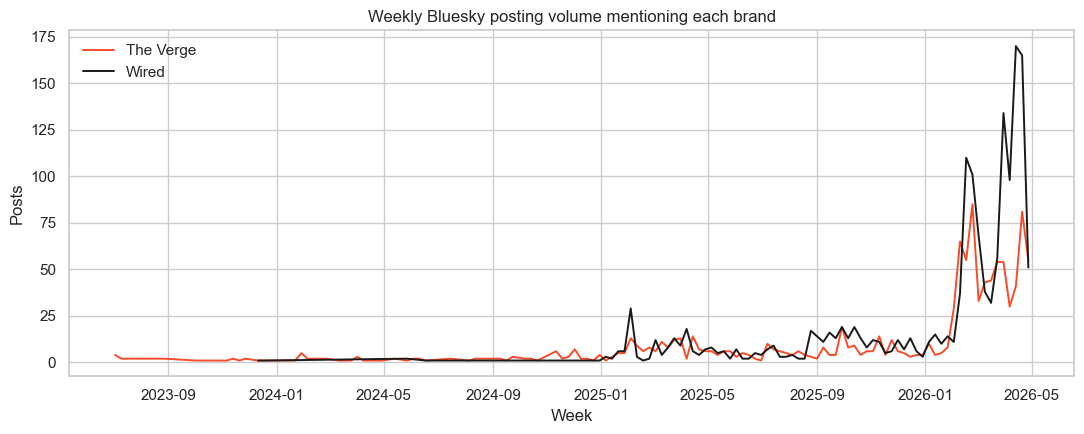

Last 12 months of posting activity:
brand    The Verge  Wired
month                    
2025-05         27     27
2025-06         15     16
2025-07         26     24
2025-08         19     27
2025-09         23     57
2025-10         41     68
2025-11         36     35
2025-12         21     40
2026-01         28     50
2026-02        229    251
2026-03        199    214
2026-04        241    607


In [241]:
# Weekly posting volume shows whether brand mentions are steady or driven by news spikes.

all_posts = all_posts.copy()

# Convert created_at to datetime first
all_posts["created_at"] = pd.to_datetime(
    all_posts["created_at"],
    errors="coerce",
    utc=True
).dt.tz_convert(None)

# Remove rows where date conversion failed
all_posts = all_posts.dropna(subset=["created_at"])

weekly = (
    all_posts
    .assign(week=lambda d: d["created_at"].dt.to_period("W").dt.start_time)
    .groupby(["week", "brand"])
    .size()
    .reset_index(name="posts")
)

fig, ax = plt.subplots(figsize=(11, 4.5))

for brand, g in weekly.groupby("brand"):
    brand_name = str(brand)

    ax.plot(
        g["week"],
        pd.to_numeric(g["posts"], errors="coerce").fillna(0).to_numpy(dtype=float),
        label=brand_name,
        color=BRAND_COLORS.get(brand_name, "grey"),
        linewidth=1.4
    )

ax.set_title("Weekly Bluesky posting volume mentioning each brand")
ax.set_xlabel("Week")
ax.set_ylabel("Posts")
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_weekly_volume.png", dpi=150, bbox_inches="tight")
plt.show()


# Monthly summary table for the report
monthly = (
    all_posts
    .assign(month=lambda d: d["created_at"].dt.to_period("M").astype(str))
    .groupby(["month", "brand"])
    .size()
    .unstack(fill_value=0)
)

print("Last 12 months of posting activity:")
print(monthly.tail(12))

monthly.to_csv(TAB_DIR / "02_monthly_volume.csv")

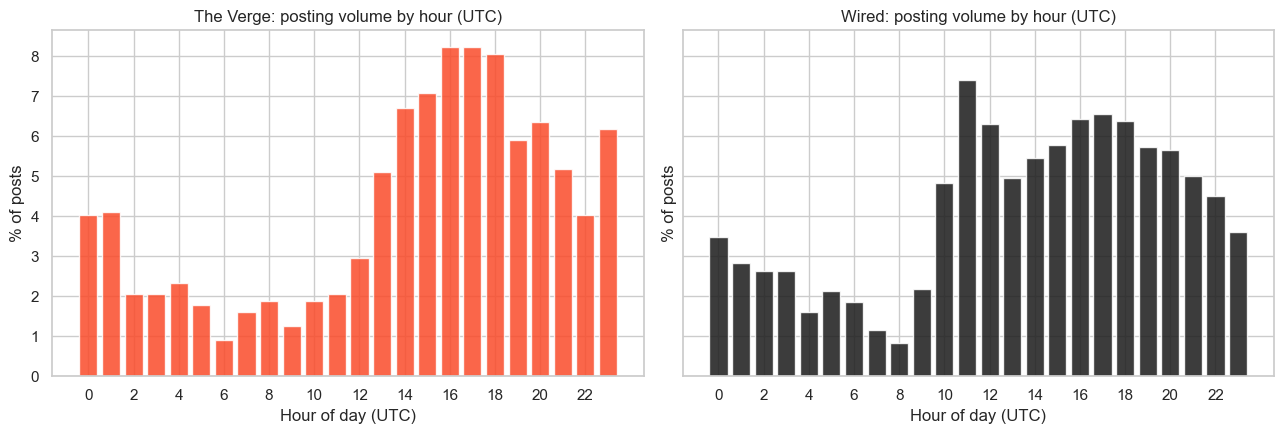

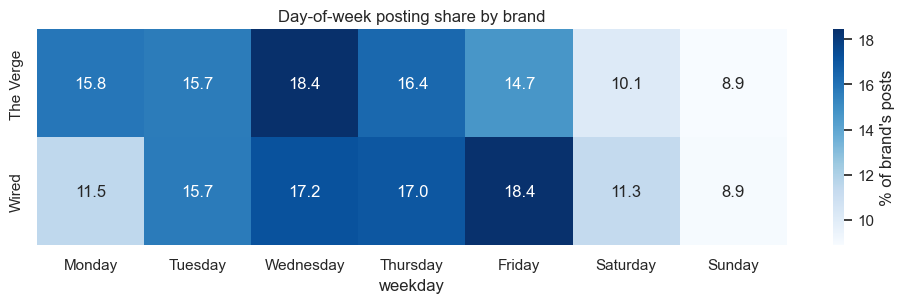

In [242]:
# Posting time-of-day distribution that Reveals whether brand discourse is driven by working-hours news cycles (publication-led) or evening leisure browsing (community-led).

all_posts["hour_utc"] = pd.to_datetime(
    all_posts["created_at"], errors="coerce", utc=True
).dt.hour
all_posts["weekday"] = pd.to_datetime(
    all_posts["created_at"], errors="coerce", utc=True
).dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (brand, g) in zip(axes, all_posts.groupby("brand")):
    hourly = g["hour_utc"].value_counts(normalize=True).sort_index() * 100
    ax.bar(hourly.index, hourly.values,
           color=BRAND_COLORS.get(str(brand), "grey"), alpha=0.85)
    ax.set_title(f"{brand}: posting volume by hour (UTC)")
    ax.set_xlabel("Hour of day (UTC)")
    ax.set_ylabel("% of posts")
    ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIG_DIR / "03b_posting_hour_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Day-of-week heatmap
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]
heat = (
    all_posts
    .groupby(["brand", "weekday"]).size()
    .unstack("weekday").reindex(columns=weekday_order)
)
heat_pct = heat.div(heat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 3.2))
sns.heatmap(heat_pct, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={"label": "% of brand's posts"}, ax=ax)
ax.set_title("Day-of-week posting share by brand")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "03c_posting_weekday_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

heat_pct.round(2).to_csv(TAB_DIR / "03c_weekday_share.csv")

Engagement summary:
brand           The Verge    Wired
n_posts           1117.00  1554.00
mean_likes           9.93    23.46
median_likes         1.00     0.00
p95_likes           38.00    51.35
max_likes          870.00  6074.00
mean_reposts         2.29     7.76
median_reposts       0.00     0.00
p95_reposts          7.00    14.00
max_reposts        389.00  2278.00
mean_replies         0.74     1.12
median_replies       0.00     0.00
p95_replies          2.00     3.00
max_replies         86.00   284.00


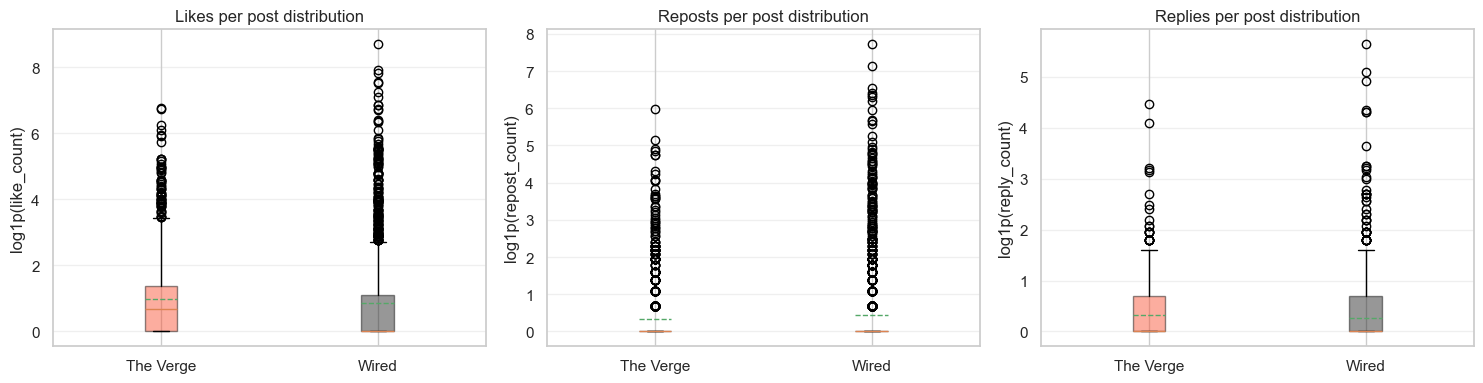

Zero-engagement share (%):
           zero_likes_share  zero_reposts_share  zero_replies_share
brand                                                              
The Verge             41.45               77.80               64.55
Wired                 54.63               76.71               74.90


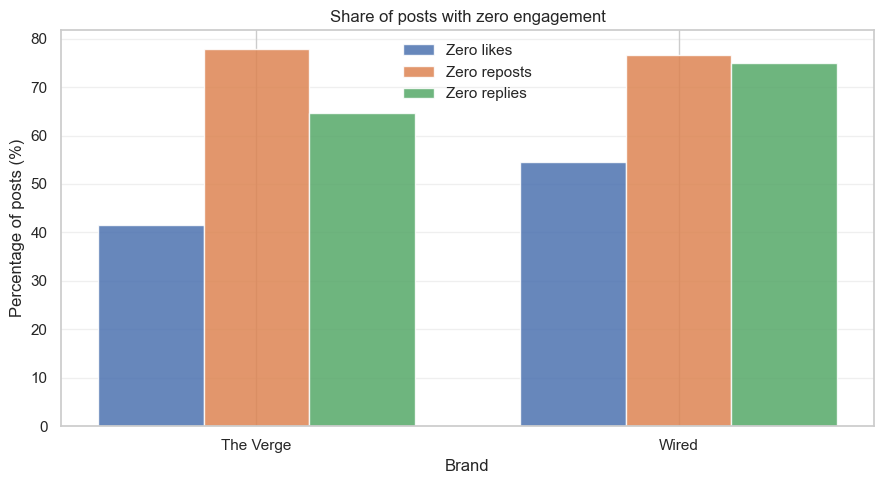

Engagement composition (%):
           total_likes  total_reposts  total_replies
brand                                               
The Verge        76.64          17.67           5.69
Wired            72.56          23.99           3.45


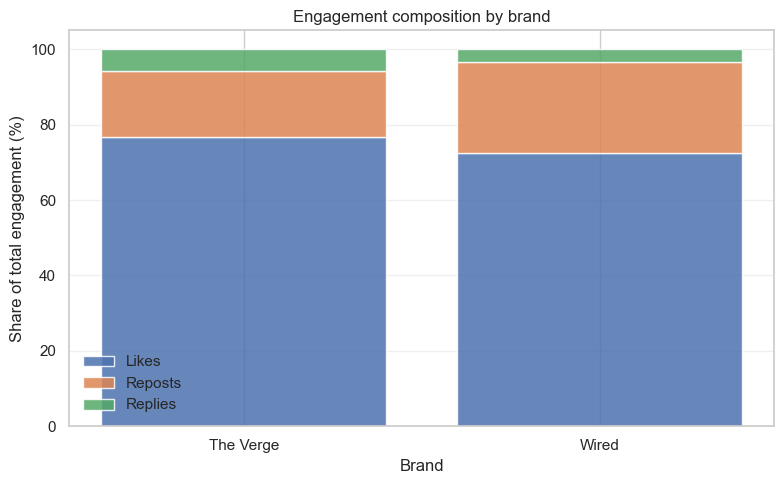

In [243]:
# Engagement summary by brand

for col in ["like_count", "repost_count", "reply_count"]:
    all_posts[col] = pd.to_numeric(all_posts[col], errors="coerce").fillna(0)

all_posts["brand"] = all_posts["brand"].astype(str)

engagement_summary = all_posts.groupby("brand").agg(
    n_posts          = ("uri",          "count"),
    mean_likes       = ("like_count",   "mean"),
    median_likes     = ("like_count",   "median"),
    p95_likes        = ("like_count",   lambda s: s.quantile(0.95)),
    max_likes        = ("like_count",   "max"),
    mean_reposts     = ("repost_count", "mean"),
    median_reposts   = ("repost_count", "median"),
    p95_reposts      = ("repost_count", lambda s: s.quantile(0.95)),
    max_reposts      = ("repost_count", "max"),
    mean_replies     = ("reply_count",  "mean"),
    median_replies   = ("reply_count",  "median"),
    p95_replies      = ("reply_count",  lambda s: s.quantile(0.95)),
    max_replies      = ("reply_count",  "max"),
).round(2)

print("Engagement summary:")
print(engagement_summary.T)

engagement_summary.T.to_csv(TAB_DIR / "03_engagement_summary.csv")

# Distribution chart: boxplots on log1p scale
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

boxplot_specs = [
    ("like_count", "Likes per post distribution"),
    ("repost_count", "Reposts per post distribution"),
    ("reply_count", "Replies per post distribution"),
]

for ax, spec in zip(axes, boxplot_specs):
    metric, title = spec

    brands = []
    data = []

    for brand_value, group_df in all_posts.groupby("brand"):
        brand_name = str(brand_value)
        brands.append(brand_name)

        values = pd.to_numeric(group_df[metric], errors="coerce").fillna(0).to_numpy(dtype=float)
        data.append(np.log1p(values))

    bp = ax.boxplot(
        data,
        tick_labels=brands,
        patch_artist=True,
        showmeans=True,
        meanline=True
    )

    for patch, brand_name in zip(bp["boxes"], brands):
        patch.set_facecolor(BRAND_COLORS.get(brand_name, "grey"))
        patch.set_alpha(0.45)

    ax.set_title(title)
    ax.set_ylabel(f"log1p({metric})")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_engagement_distribution_log.png", dpi=150, bbox_inches="tight")
plt.show()

# Zero-engagement share chart
zero_summary = all_posts.groupby("brand").agg(
    zero_likes_share   = ("like_count",   lambda s: (s == 0).mean() * 100),
    zero_reposts_share = ("repost_count", lambda s: (s == 0).mean() * 100),
    zero_replies_share = ("reply_count",  lambda s: (s == 0).mean() * 100),
).round(2)

print("Zero-engagement share (%):")
print(zero_summary)

zero_summary.to_csv(TAB_DIR / "04_zero_engagement_share.csv")

zero_plot = zero_summary.reset_index().melt(
    id_vars="brand",
    value_vars=["zero_likes_share", "zero_reposts_share", "zero_replies_share"],
    var_name="Metric",
    value_name="Percentage"
)

zero_plot["Metric"] = zero_plot["Metric"].replace({
    "zero_likes_share": "Zero likes",
    "zero_reposts_share": "Zero reposts",
    "zero_replies_share": "Zero replies"
})

fig, ax = plt.subplots(figsize=(9, 5))

brands = zero_plot["brand"].astype(str).unique().tolist()
metrics = zero_plot["Metric"].unique().tolist()

x = np.arange(len(brands))
width = 0.25

for i, metric in enumerate(metrics):
    values = (
        zero_plot[zero_plot["Metric"] == metric]
        .set_index("brand")
        .loc[brands, "Percentage"]
        .to_numpy(dtype=float)
    )

    ax.bar(
        x + (i - 1) * width,
        values,
        width,
        label=metric,
        alpha=0.85
    )

ax.set_title("Share of posts with zero engagement")
ax.set_ylabel("Percentage of posts (%)")
ax.set_xlabel("Brand")
ax.set_xticks(x)
ax.set_xticklabels(brands)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_zero_engagement_share.png", dpi=150, bbox_inches="tight")
plt.show()

# Engagement composition chart
composition_summary = all_posts.groupby("brand").agg(
    total_likes   = ("like_count",   "sum"),
    total_reposts = ("repost_count", "sum"),
    total_replies = ("reply_count",  "sum"),
)

composition_pct = composition_summary.div(composition_summary.sum(axis=1), axis=0) * 100
composition_pct = composition_pct.fillna(0).round(2)

print("Engagement composition (%):")
print(composition_pct)

composition_pct.to_csv(TAB_DIR / "05_engagement_composition.csv")

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(composition_pct))

for col in composition_pct.columns:
    ax.bar(
        composition_pct.index.astype(str),
        composition_pct[col].to_numpy(dtype=float),
        bottom=bottom,
        label=col.replace("total_", "").title(),
        alpha=0.85
    )

    bottom += composition_pct[col].to_numpy(dtype=float)

ax.set_title("Engagement composition by brand")
ax.set_ylabel("Share of total engagement (%)")
ax.set_xlabel("Brand")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_engagement_composition.png", dpi=150, bbox_inches="tight")
plt.show()

    brand          hashtag  count
    Wired         #devnews    340
    Wired #machinelearning    119
    Wired        #tutorial     58
    Wired           #tools     32
    Wired        #csulbsoc     18
    Wired        #security     17
    Wired              #ai     15
    Wired           #wired     12
    Wired  #webdevelopment     12
    Wired          #devops     11
    Wired            #tech      6
    Wired          #edtech      6
    Wired         #systems      6
    Wired            #doge      5
    Wired          #edusky      5
The Verge              #ai     20
The Verge        #csulbsoc     11
The Verge            #news      9
The Verge          #openai      5
The Verge        #theverge      4
The Verge            #musk      4
The Verge            #meta      4
The Verge   #teslatakedown      3
The Verge   #cybersecurity      3
The Verge     #socialmedia      3
The Verge           #linux      3
The Verge           #media      3
The Verge       #anthropic      2
The Verge     

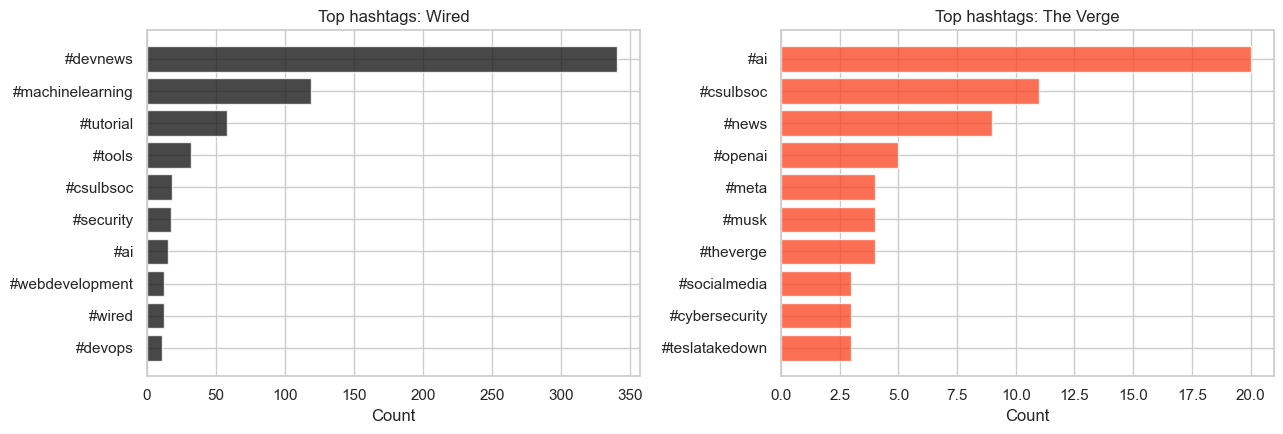

In [244]:
def top_hashtags(df: pd.DataFrame, n: int = 15) -> list[tuple[str, int]]:
    flat = []
    for tag_str in df["hashtags"].dropna().astype(str):
        if not tag_str:
            continue
        flat.extend([x for x in tag_str.split(";") if x])
    return Counter(flat).most_common(n)

hashtags_rows = []
for brand, df in [("Wired", wired_posts), ("The Verge", verge_posts)]:
    for tag, count in top_hashtags(df, 15):
        hashtags_rows.append({"brand": brand, "hashtag": tag, "count": count})

hashtags_df = pd.DataFrame(hashtags_rows)
print(hashtags_df.to_string(index=False))
hashtags_df.to_csv(TAB_DIR / "05_top_hashtags.csv", index=False)

# Plot top 10 per brand
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, brand in zip(axes, ["Wired", "The Verge"]):
    g = hashtags_df[hashtags_df["brand"] == brand].head(10).copy()
    if g.empty:
        ax.set_title(f"{brand}: no hashtags")
        ax.axis("off")
        continue

    g = g.sort_values("count", ascending=True)

    ax.barh(
        g["hashtag"],
        pd.to_numeric(g["count"], errors="coerce").fillna(0).to_numpy(dtype=float),
        color=BRAND_COLORS.get(brand, "grey"),
        alpha=0.8
    )
    ax.set_title(f"Top hashtags: {brand}")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_top_hashtags.png", dpi=150, bbox_inches="tight")
plt.show()

In [245]:
# What other sources do users link to alongside the brand? This is a proxy for the media ecosystem each brand sits inside a perceptual-map signal.
EXCLUDE_DOMAINS = {
    "wired.com", "wired.co.uk", "theverge.com", "bsky.app",
    "www.wired.com", "www.theverge.com"
}

def top_domains(df: pd.DataFrame, n: int = 15) -> list[tuple[str, int]]:
    domains = []
    for dom_str in df["domains"].dropna().astype(str):
        for d in dom_str.split(";"):
            d = d.lower().strip()
            if d and d not in EXCLUDE_DOMAINS:
                domains.append(d)
    return Counter(domains).most_common(n)

domain_rows = []
for brand, df in [("Wired", wired_posts), ("The Verge", verge_posts)]:
    for dom, count in top_domains(df, 15):
        domain_rows.append({"brand": brand, "domain": dom, "count": count})

domains_df = pd.DataFrame(domain_rows)
print(domains_df.to_string(index=False))
domains_df.to_csv(TAB_DIR / "06_top_linked_domains.csv", index=False)

    brand                         domain  count
    Wired                 flarestart.com    340
    Wired                       youtu.be     28
    Wired                    youtube.com     11
    Wired                     tiktok.com      9
    Wired                    nytimes.com      8
    Wired                 techcrunch.com      8
    Wired             talkingbiznews.com      7
    Wired      noahshachtman.bsky.social      7
    Wired                   futurism.com      7
    Wired                     apple.news      6
    Wired oversightdemocrats.bsky.social      6
    Wired                theatlantic.com      5
    Wired                     archive.ph      5
    Wired    robertsilverman.bsky.social      5
    Wired       taylorlorenz.bsky.social      5
The Verge           reckless.bsky.social     61
The Verge                davidpierce.xyz     28
The Verge                      index.xml     14
The Verge                    reuters.com     14
The Verge                       youtu.be

In [246]:
# Per-author rollup feeds Phase 7's micro-influencer scoring directly.
def author_summary(posts: pd.DataFrame, profiles: pd.DataFrame) -> pd.DataFrame:
    by_author = posts.groupby("author_did").agg(
        posts          = ("uri",          "count"),
        total_likes    = ("like_count",   "sum"),
        total_reposts  = ("repost_count", "sum"),
        total_replies  = ("reply_count",  "sum"),
        mean_likes     = ("like_count",   "mean"),
        mean_reposts   = ("repost_count", "mean"),
    ).reset_index()
    by_author = by_author.merge(
        profiles[["did", "handle", "display_name",
                  "followers_count", "follows_count",
                  "follower_following_ratio"]],
        left_on="author_did", right_on="did", how="left",
    )
    return by_author.drop(columns="did")

wired_authors = author_summary(wired_posts, wired_profiles)
verge_authors = author_summary(verge_posts, verge_profiles)

print("=== Wired – top 10 by post volume ===")
print(wired_authors.nlargest(10, "posts")[
    ["handle", "posts", "total_likes", "total_reposts", "followers_count"]
].to_string(index=False))

print("\n=== The Verge – top 10 by post volume ===")
print(verge_authors.nlargest(10, "posts")[
    ["handle", "posts", "total_likes", "total_reposts", "followers_count"]
].to_string(index=False))

print("\n=== Wired – top 10 by total likes received ===")
print(wired_authors.nlargest(10, "total_likes")[
    ["handle", "posts", "total_likes", "total_reposts", "followers_count"]
].to_string(index=False))

print("\n=== The Verge – top 10 by total likes received ===")
print(verge_authors.nlargest(10, "total_likes")[
    ["handle", "posts", "total_likes", "total_reposts", "followers_count"]
].to_string(index=False))

# Persist for Phase 7 (micro-influencer identification)
wired_authors.to_csv(TAB_DIR / "04_wired_author_summary.csv", index=False)
verge_authors.to_csv(TAB_DIR / "04_verge_author_summary.csv", index=False)

=== Wired – top 10 by post volume ===
                      handle  posts  total_likes  total_reposts  followers_count
      flarestart.bsky.social    340           16              3               97
     ainieuwtjes.bsky.social    101           19              2               24
christinaayiotis.bsky.social     17            8              3              862
  semireflection.bsky.social     11            6              2            11235
   noahshachtman.bsky.social     10         2804            819           167352
     jeremywired.bsky.social      9          205             30            13538
                agentwyre.ai      9            3              1               56
  katie-drummond.bsky.social      8         2481            762            72052
      thiccreese.bsky.social      8          358             80            18267
                 surf.social      7          150             34             3983

=== The Verge – top 10 by post volume ===
                            

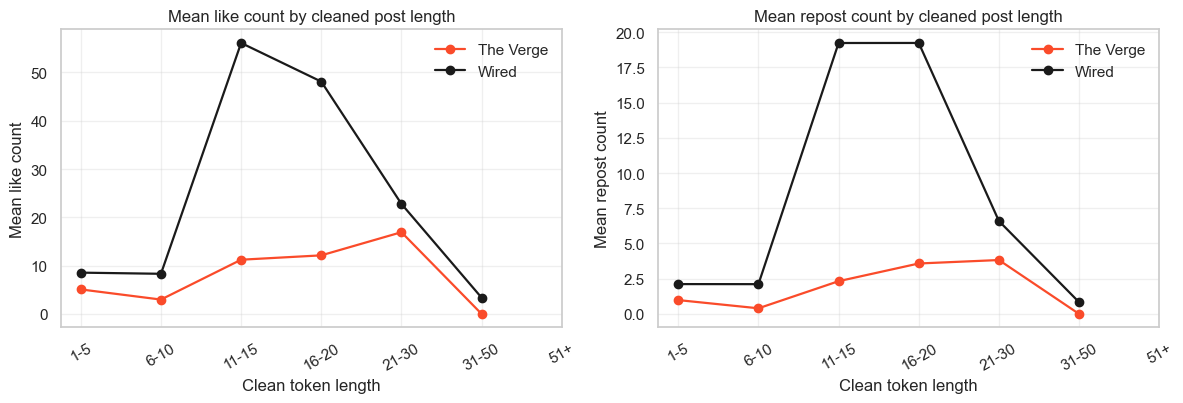

                    n_posts  mean_likes  mean_reposts
brand     is_reply                                   
The Verge False         705       12.89          3.27
          True          412        4.86          0.61
Wired     False        1241       28.11          9.56
          True          313        5.04          0.61


In [247]:
length_bins = [0, 5, 10, 15, 20, 30, 50, 200]
length_labels = ["1-5", "6-10", "11-15", "16-20", "21-30", "31-50", "51+"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, metric in zip(axes, ["like_count", "repost_count"]):
    for brand, g in all_posts.groupby("brand"):
        brand_name = str(brand)

        bins = pd.cut(
            pd.to_numeric(g["word_count_clean"], errors="coerce").fillna(0),
            bins=length_bins,
            labels=length_labels
        )

        binned = (
            g.assign(length_bin=bins)
            .groupby("length_bin", observed=True)[metric]
            .mean()
            .reindex(length_labels)
        )

        ax.plot(
            range(len(length_labels)),
            pd.to_numeric(binned, errors="coerce").to_numpy(dtype=float),
            marker="o",
            label=brand_name,
            color=BRAND_COLORS.get(brand_name, "grey"),
            linewidth=1.6
        )

    ax.set_xticks(range(len(length_labels)))
    ax.set_xticklabels(length_labels, rotation=30)
    ax.set_title(f"Mean {metric.replace('_', ' ')} by cleaned post length")
    ax.set_xlabel("Clean token length")
    ax.set_ylabel(f"Mean {metric.replace('_', ' ')}")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_engagement_by_post_length.png", dpi=150, bbox_inches="tight")
plt.show()

post_type_summary = all_posts.groupby(["brand", "is_reply"]).agg(
    n_posts=("uri", "count"),
    mean_likes=("like_count", "mean"),
    mean_reposts=("repost_count", "mean"),
).round(2)
print(post_type_summary)
post_type_summary.to_csv(TAB_DIR / "07_post_type_engagement.csv")

In [248]:
# Distil the analysis into a JSON the methodology / analysis sections can quote.

post_type_summary_json = {}

for idx, metrics in post_type_summary.to_dict("index").items():
    if isinstance(idx, tuple):
        brand, is_reply = idx
        key = f"{brand}_{'reply' if is_reply else 'original'}"
    else:
        key = str(idx)

    clean_metrics = {}
    for metric_name, value in metrics.items():
        if pd.isna(value):
            clean_metrics[metric_name] = None
        elif isinstance(value, (np.integer, int)):
            clean_metrics[metric_name] = int(value)
        else:
            clean_metrics[metric_name] = float(value)

    post_type_summary_json[key] = clean_metrics

eda_summary = {
    "n_posts": {
        "wired": int(len(wired_posts)),
        "the_verge": int(len(verge_posts)),
        "combined": int(len(all_posts)),
    },
    "n_authors": {
        "wired": int(wired_posts["author_did"].nunique()),
        "the_verge": int(verge_posts["author_did"].nunique()),
    },
    "date_ranges": {
        "wired": [str(wired_posts["created_at"].min()), str(wired_posts["created_at"].max())],
        "the_verge": [str(verge_posts["created_at"].min()), str(verge_posts["created_at"].max())],
    },
    "engagement_summary": engagement_summary.reset_index().to_dict("records"),
    "top_hashtags": hashtags_df.to_dict("records"),
    "top_domains": domains_df.to_dict("records"),
    "post_type_summary": post_type_summary_json,
}

with open(PROC_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2, default=str)

print("Saved EDA summary to data/processed/eda_summary.json")

Saved EDA summary to data/processed/eda_summary.json


## 4. Sentiment Analysis (VADER)

In [249]:
#Sentiment Analysis

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts = pd.read_csv(PROC_DIR / "wired_posts_clean.csv", parse_dates=["created_at"])
verge_posts = pd.read_csv(PROC_DIR / "verge_posts_clean.csv", parse_dates=["created_at"])

wired_posts["brand"] = "Wired"
verge_posts["brand"] = "The Verge"
all_posts = pd.concat([wired_posts, verge_posts], ignore_index=True)

print(f"Loaded {len(all_posts)} cleaned posts for sentiment analysis.")

Loaded 2731 cleaned posts for sentiment analysis.


In [250]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    if not isinstance(text, str) or not text.strip():
        return 0.0
    ret = analyzer.polarity_scores(text)
    return cast(float, ret["compound"])

all_posts["vader_compound"] = all_posts["text_for_sentiment"].apply(vader_compound)
all_posts["sentiment_label"] = pd.cut(
    all_posts["vader_compound"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"]
)

sent_summary = all_posts.groupby("brand").agg(
    n_posts        = ("uri", "count"),
    mean_compound  = ("vader_compound", "mean"),
    median_compound= ("vader_compound", "median"),
    pct_positive   = ("sentiment_label", lambda s: (s == "positive").mean() * 100),
    pct_neutral    = ("sentiment_label", lambda s: (s == "neutral").mean() * 100),
    pct_negative   = ("sentiment_label", lambda s: (s == "negative").mean() * 100),
).round(3)

print(sent_summary.T)
sent_summary.T.to_csv(TAB_DIR / "08_sentiment_summary.csv")

# Save scored posts for downstream topic/influencer/perceptual map steps
wired_scored = all_posts[all_posts["brand"] == "Wired"].drop(columns="brand")
verge_scored = all_posts[all_posts["brand"] == "The Verge"].drop(columns="brand")
wired_scored.to_csv(PROC_DIR / "wired_posts_sentiment.csv", index=False)
verge_scored.to_csv(PROC_DIR / "verge_posts_sentiment.csv", index=False)

brand            The Verge     Wired
n_posts           1153.000  1578.000
mean_compound        0.137     0.078
median_compound      0.009     0.000
pct_positive        49.436    43.599
pct_neutral         23.417    26.616
pct_negative        27.147    29.785


High-engagement class balance:
brand
The Verge    0.235
Wired        0.234
Name: high_eng, dtype: float64
                           Logit Regression Results                           
Dep. Variable:               high_eng   No. Observations:                 2731
Model:                          Logit   Df Residuals:                     2724
Method:                           MLE   Df Model:                            6
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                 0.05763
Time:                        13:06:38   Log-Likelihood:                -1402.4
converged:                       True   LL-Null:                       -1488.1
Covariance Type:            nonrobust   LLR p-value:                 2.143e-34
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9722      0.139     -6.983      0.000      -1.245      -0.699
polarity         0.

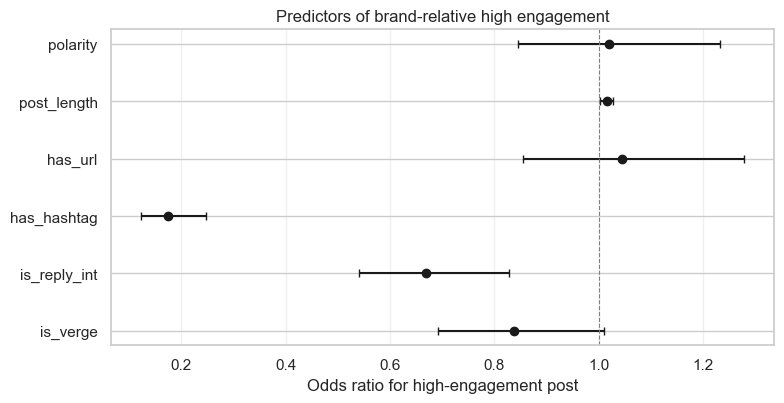

In [251]:
# Logistic regression: what predicts a high-engagement post?
# Outcome: post is in the top quartile of engagement within its brand.
# Predictors: VADER polarity, post length, has_url, has_hashtag, is_reply, brand dummy.

import statsmodels.api as sm

reg = all_posts.copy()

for col in ["like_count", "repost_count", "reply_count"]:
    reg[col] = pd.to_numeric(reg[col], errors="coerce").fillna(0)

reg["engagement_score"] = reg["like_count"] + reg["repost_count"] + reg["reply_count"]

reg["high_eng"] = (
    reg.groupby("brand")["engagement_score"]
       .transform(lambda s: (s > s.quantile(0.75)).astype(int))
)

reg["has_url"]      = (pd.to_numeric(reg["n_urls"],     errors="coerce").fillna(0) > 0).astype(int)
reg["has_hashtag"]  = (pd.to_numeric(reg["n_hashtags"], errors="coerce").fillna(0) > 0).astype(int)
reg["is_reply_int"] = pd.to_numeric(reg["is_reply"], errors="coerce").fillna(0).astype(int)
reg["post_length"]  = pd.to_numeric(reg["word_count_clean"], errors="coerce").fillna(0)
reg["is_verge"]     = (reg["brand"] == "The Verge").astype(int)
reg["polarity"]     = pd.to_numeric(reg["vader_compound"], errors="coerce").fillna(0)

print("High-engagement class balance:")
print(reg.groupby("brand")["high_eng"].mean().round(3))

X_cols = ["polarity", "post_length", "has_url", "has_hashtag",
          "is_reply_int", "is_verge"]

model_data = reg[X_cols + ["high_eng"]].replace([np.inf, -np.inf], np.nan).dropna()

X = sm.add_constant(model_data[X_cols].astype(float))
y = model_data["high_eng"].astype(int)

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

# Odds ratios with 95% CIs
or_df = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "ci_low":     np.exp(model.conf_int()[0]),
    "ci_high":    np.exp(model.conf_int()[1]),
    "p_value":    model.pvalues.round(4),
}).round(3)

print("\nOdds ratios (95% CI):")
print(or_df.to_string())

or_df.to_csv(TAB_DIR / "06b_engagement_logit.csv")

# Forest plot
fig, ax = plt.subplots(figsize=(8, 4.2))

keep = or_df.drop(index="const", errors="ignore").iloc[::-1]

ax.errorbar(
    x=keep["odds_ratio"],
    y=range(len(keep)),
    xerr=[
        keep["odds_ratio"] - keep["ci_low"],
        keep["ci_high"] - keep["odds_ratio"]
    ],
    fmt="o",
    color="#1A1A1A",
    capsize=3
)

ax.axvline(1, ls="--", color="grey", lw=0.8)
ax.set_yticks(range(len(keep)))
ax.set_yticklabels(keep.index)
ax.set_xlabel("Odds ratio for high-engagement post")
ax.set_title("Predictors of brand-relative high engagement")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "06b_engagement_logit_forest.png", dpi=150, bbox_inches="tight")
plt.show()

Sentiment label share (%):
sentiment_label  negative  neutral  positive
brand                                       
The Verge           27.15    23.42     49.44
Wired               29.78    26.62     43.60


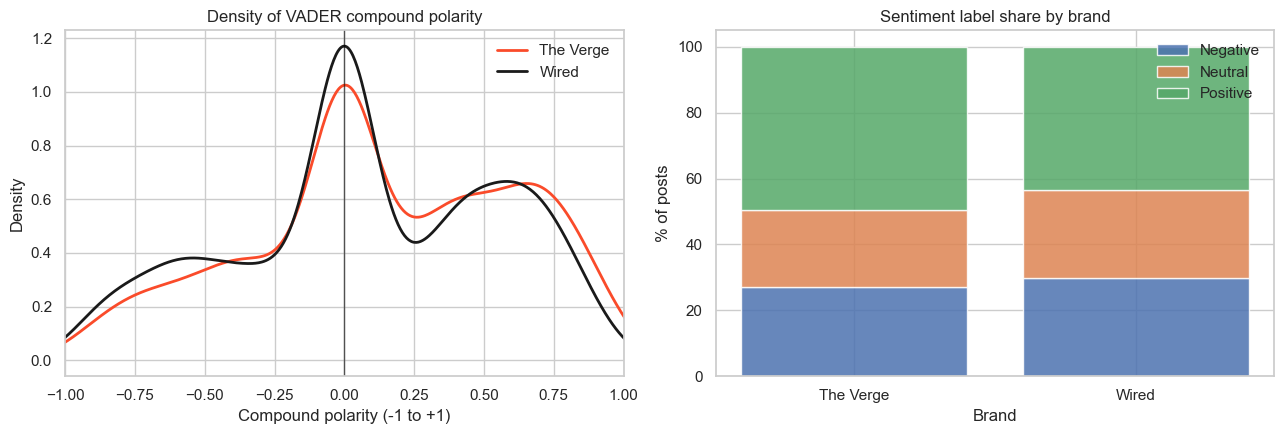

In [252]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Polarity density plot
ax = axes[0]

for brand, g in all_posts.groupby("brand"):
    brand_name = str(brand)

    values = pd.to_numeric(g["vader_compound"], errors="coerce").dropna().to_numpy(dtype=float)

    pd.Series(values).plot(
        kind="kde",
        ax=ax,
        label=brand_name,
        color=BRAND_COLORS.get(brand_name, "grey"),
        linewidth=2
    )

ax.axvline(0, color="black", linewidth=1, alpha=0.6)
ax.set_xlim(-1, 1)
ax.set_title("Density of VADER compound polarity")
ax.set_xlabel("Compound polarity (-1 to +1)")
ax.set_ylabel("Density")
ax.legend(frameon=False)


# Label share stacked bar
label_counts_raw = (
    all_posts
    .groupby(["brand", "sentiment_label"], observed=False)
    .size()
    .reset_index(name="count")
)

label_counts_raw["pct"] = (
    label_counts_raw["count"] /
    label_counts_raw.groupby("brand")["count"].transform("sum") * 100
)

label_counts = label_counts_raw[["brand", "sentiment_label", "pct"]]

label_pivot = label_counts.pivot(
    index="brand",
    columns="sentiment_label",
    values="pct"
).fillna(0)

label_pivot = label_pivot.reindex(columns=["negative", "neutral", "positive"], fill_value=0)

print("Sentiment label share (%):")
print(label_pivot.round(2))

label_pivot.round(2).to_csv(TAB_DIR / "08_sentiment_label_share.csv")

ax = axes[1]
bottom = np.zeros(len(label_pivot))

for label in ["negative", "neutral", "positive"]:
    values = pd.to_numeric(label_pivot[label], errors="coerce").fillna(0).to_numpy(dtype=float)

    ax.bar(
        label_pivot.index.astype(str),
        values,
        bottom=bottom,
        label=label.title(),
        alpha=0.85
    )

    bottom += values

ax.set_title("Sentiment label share by brand")
ax.set_ylabel("% of posts")
ax.set_xlabel("Brand")
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

15-day sentiment summary:
           periods  mean_of_means  min_mean  max_mean  mean_posts_per_period
brand                                                                       
The Verge       28          0.120    -0.289     0.419                 36.893
Wired           26          0.084    -0.316     0.345                 58.615

Most negative 15-day periods:
                  period_15d      brand  mean_compound  median_compound  \
63 2025-06-26 00:00:00+00:00      Wired         -0.316           -0.477   
56 2025-05-12 00:00:00+00:00  The Verge         -0.289           -0.315   
87 2025-12-23 00:00:00+00:00      Wired         -0.211           -0.248   
88 2026-01-07 00:00:00+00:00  The Verge         -0.119           -0.193   
46 2025-02-26 00:00:00+00:00  The Verge         -0.084            0.000   
78 2025-10-24 00:00:00+00:00  The Verge         -0.070            0.000   
54 2025-04-27 00:00:00+00:00  The Verge         -0.028            0.000   
47 2025-02-26 00:00:00+00:00      W

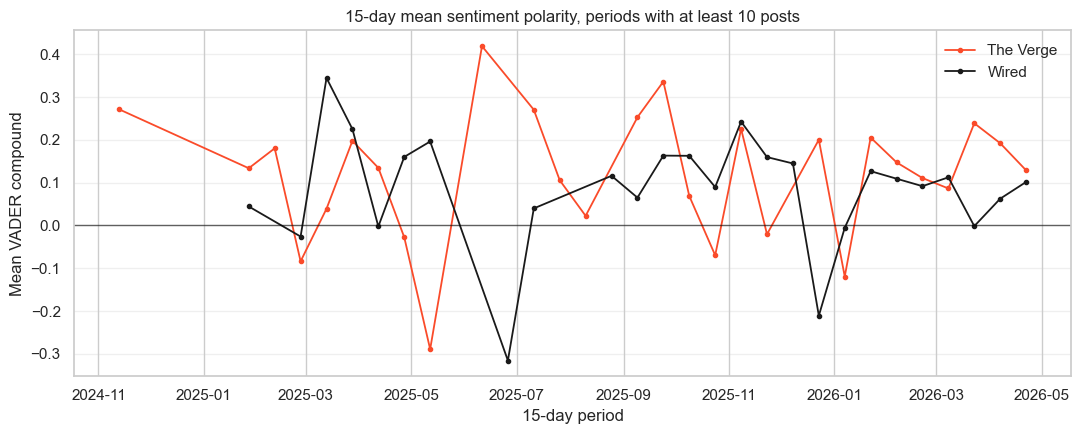

In [253]:
# 15-day mean polarity, gated to periods with at least 10 posts.

all_posts = all_posts.copy()

# Fix mixed timestamp formats
all_posts["created_at"] = pd.to_datetime(
    all_posts["created_at"],
    errors="coerce",
    utc=True,
    format="mixed"
)

# Ensure sentiment is numeric
all_posts["vader_compound"] = pd.to_numeric(
    all_posts["vader_compound"],
    errors="coerce"
)

period_posts = (
    all_posts
    .dropna(subset=["created_at", "vader_compound"])
    .assign(
        period_15d=lambda d: d["created_at"].dt.floor("15D")
    )
)

period_sent = (
    period_posts
    .groupby(["period_15d", "brand"])
    .agg(
        mean_compound=("vader_compound", "mean"),
        median_compound=("vader_compound", "median"),
        n_posts=("uri", "count")
    )
    .reset_index()
)

period_sent = period_sent[period_sent["n_posts"] >= 10]

print("15-day sentiment summary:")
print(
    period_sent
    .groupby("brand")
    .agg(
        periods=("period_15d", "count"),
        mean_of_means=("mean_compound", "mean"),
        min_mean=("mean_compound", "min"),
        max_mean=("mean_compound", "max"),
        mean_posts_per_period=("n_posts", "mean")
    )
    .round(3)
)

print("\nMost negative 15-day periods:")
print(
    period_sent[period_sent["mean_compound"] < 0]
    [["period_15d", "brand", "mean_compound", "median_compound", "n_posts"]]
    .sort_values("mean_compound")
    .head(8)
    .round(3)
)

period_sent.to_csv(TAB_DIR / "09_15day_sentiment.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 4.5))

for brand, g in period_sent.groupby("brand"):
    brand_name = str(brand)

    g = g.sort_values("period_15d")

    ax.plot(
        g["period_15d"],
        pd.to_numeric(g["mean_compound"], errors="coerce").to_numpy(dtype=float),
        marker="o",
        markersize=3,
        linewidth=1.3,
        label=brand_name,
        color=BRAND_COLORS.get(brand_name, "grey")
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_title("15-day mean sentiment polarity, periods with at least 10 posts")
ax.set_xlabel("15-day period")
ax.set_ylabel("Mean VADER compound")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "09_15day_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

Engagement by sentiment label:
       brand sentiment_label  n_posts  mean_likes  median_likes  p95_likes  \
0  The Verge        negative      313       12.26           1.0      62.60   
1  The Verge         neutral      270        6.89           0.0      19.00   
2  The Verge        positive      570        9.55           1.0      45.65   
3      Wired        negative      470       45.33           0.0      99.65   
4      Wired         neutral      420        8.18           0.0      20.05   
5      Wired        positive      688       17.05           0.0      52.00   

   mean_reposts  median_reposts  p95_reposts  
0          3.33             0.0         13.8  
1          2.05             0.0          3.0  
2          1.73             0.0          7.0  
3         17.43             0.0         29.1  
4          2.32             0.0          6.0  
5          4.24             0.0         15.0  


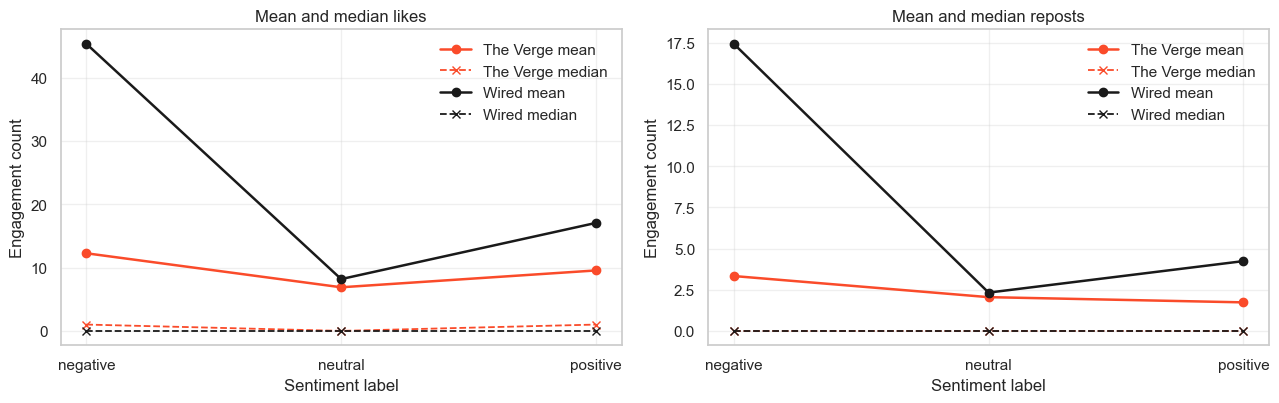

In [254]:
# Engagement by sentiment label

sentiment_order = ["negative", "neutral", "positive"]

eng_by_sent = (
    all_posts.groupby(["brand", "sentiment_label"], observed=False)
    .agg(
        n_posts=("uri", "count"),
        mean_likes=("like_count", "mean"),
        median_likes=("like_count", "median"),
        p95_likes=("like_count", lambda s: s.quantile(0.95)),
        mean_reposts=("repost_count", "mean"),
        median_reposts=("repost_count", "median"),
        p95_reposts=("repost_count", lambda s: s.quantile(0.95)),
    )
    .reset_index()
)

eng_by_sent.to_csv(TAB_DIR / "09_engagement_by_sentiment.csv", index=False)

print("Engagement by sentiment label:")
print(eng_by_sent.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

plot_specs = [
    ("mean_likes", "median_likes", "Mean and median likes"),
    ("mean_reposts", "median_reposts", "Mean and median reposts"),
]

for ax, spec in zip(axes, plot_specs):
    mean_col, median_col, title = spec

    for brand, g in eng_by_sent.groupby("brand"):
        brand_name = str(brand)

        g = (
            g.set_index("sentiment_label")
            .reindex(sentiment_order)
            .reset_index()
        )

        x = np.arange(len(sentiment_order))

        ax.plot(
            x,
            pd.to_numeric(g[mean_col], errors="coerce").fillna(0).to_numpy(dtype=float),
            marker="o",
            linewidth=1.8,
            label=f"{brand_name} mean",
            color=BRAND_COLORS.get(brand_name, "grey")
        )

        ax.plot(
            x,
            pd.to_numeric(g[median_col], errors="coerce").fillna(0).to_numpy(dtype=float),
            marker="x",
            linewidth=1.3,
            linestyle="--",
            label=f"{brand_name} median",
            color=BRAND_COLORS.get(brand_name, "grey")
        )

    ax.set_title(title)
    ax.set_xlabel("Sentiment label")
    ax.set_ylabel("Engagement count")
    ax.set_xticks(x)
    ax.set_xticklabels(sentiment_order)
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "10_engagement_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

In [255]:
# A handful of examples per pole useful for the Analysis section to ground the numbers in real text truncated to 200 chars to keep output readable.
def show_examples(df: pd.DataFrame, brand: str, n: int = 4):
    print(f"\n=== {brand}: most positive examples ===")
    display_cols = ["author_handle", "vader_compound", "like_count", "text_raw"]
    print(df[df["brand"] == brand].nlargest(n, "vader_compound")[display_cols].to_string(index=False, max_colwidth=200))
    print(f"\n=== {brand}: most negative examples ===")
    print(df[df["brand"] == brand].nsmallest(n, "vader_compound")[display_cols].to_string(index=False, max_colwidth=200))

show_examples(all_posts, "Wired")
show_examples(all_posts, "The Verge")


=== Wired: most positive examples ===
                author_handle  vader_compound  like_count                                                                                                                                                                                                 text_raw
  michaelmechanic.bsky.social          0.9617           4                                                                    Congrats to our friends at @wired.com for their excellent DOGE coverage, which just won them the Sidney Hillman Prize. Well deserved!
   katie-drummond.bsky.social          0.9501         242                         Thrilled, honored, and so proud of @wired.com for winning the 2026 Hillman Prize for Magazine Journalism:\n\n"WIRED’s stories were not only groundbreaking; they were singular."
intolerantleftest.bsky.social          0.9482           1 EVERYONE CALM DOWN THE ADL SAID IT'S COOL\n\nYou know cuz he is pro israel...\n\nWIRED REPORTS: "Neo-Nazis Love the Nazi-Like 

In [256]:
# Author-level sentiment feeds directly into Phase 7's micro-influencer scoring.
def author_sentiment(posts: pd.DataFrame) -> pd.DataFrame:
    return (
        posts.groupby("author_did").agg(
            mean_compound=("vader_compound", "mean"),
            pct_positive=("sentiment_label", lambda s: (s == "positive").mean() * 100),
            pct_negative=("sentiment_label", lambda s: (s == "negative").mean() * 100),
            n_sent_posts=("uri", "count"),
        )
        .reset_index()
    )

wired_author_sent = author_sentiment(all_posts[all_posts["brand"] == "Wired"])
verge_author_sent = author_sentiment(all_posts[all_posts["brand"] == "The Verge"])

wired_author_sent.to_csv(TAB_DIR / "10_wired_author_sentiment.csv", index=False)
verge_author_sent.to_csv(TAB_DIR / "10_verge_author_sentiment.csv", index=False)

sentiment_summary_json = {
    "brand_summary": sent_summary.reset_index().to_dict("records"),
    "engagement_by_sentiment": eng_by_sent.to_dict("records"),
    "interpretation_notes": [
        "VADER was applied to lightly cleaned text so punctuation/emphasis cues were preserved.",
        "Compound thresholds follow common VADER convention: <= -0.05 negative, >= 0.05 positive.",
        "Author-level mean polarity is saved for micro-influencer screening."
    ],
}
with open(PROC_DIR / "sentiment_summary.json", "w") as f:
    json.dump(sentiment_summary_json, f, indent=2, default=str)

print("Saved sentiment summary and author-level sentiment tables.")

Saved sentiment summary and author-level sentiment tables.


## 5. Topic Modelling, Keyword Frequency & Co-occurrence

In [257]:
# Topic Modelling, Keyword Frequency & Co-occurrence

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts = pd.read_csv(PROC_DIR / "wired_posts_sentiment.csv", parse_dates=["created_at"])
verge_posts = pd.read_csv(PROC_DIR / "verge_posts_sentiment.csv", parse_dates=["created_at"])
wired_posts["brand"] = "Wired"
verge_posts["brand"] = "The Verge"
all_posts = pd.concat([wired_posts, verge_posts], ignore_index=True)

print(f"Loaded sentiment-scored posts: {len(all_posts)}")

Loaded sentiment-scored posts: 2731


    brand     token  count
    Wired  magazine    314
    Wired    report    219
    Wired       new    137
    Wired   article    119
    Wired     story    111
    Wired     trump     95
    Wired   company     88
    Wired    people     83
    Wired      data     80
    Wired      read     78
    Wired      best     71
    Wired      year     70
    Wired      tech     70
    Wired      musk     65
    Wired      doge     61
The Verge   article    375
The Verge    report    100
The Verge according     97
The Verge     story     91
The Verge      read     80
The Verge    people     75
The Verge       new     73
The Verge      time     66
The Verge      tech     62
The Verge      link     61
The Verge   company     59
The Verge      good     59
The Verge    google     57
The Verge       say     53
The Verge      year     52


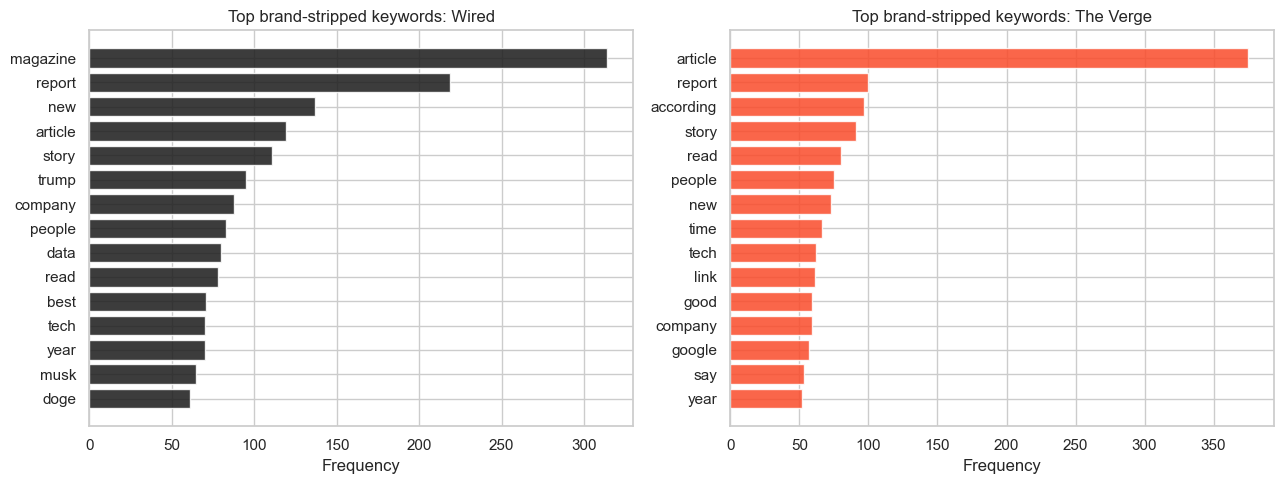

In [258]:
def top_keywords(df: pd.DataFrame, col: str = "text_clean_no_brand", n: int = 25) -> list[tuple[str, int]]:
    counter = Counter()
    for txt in df[col]:
        if txt:
            counter.update(str(txt).split())
    return counter.most_common(n)

kw_rows = []
for brand, df in [("Wired", wired_posts), ("The Verge", verge_posts)]:
    for token, count in top_keywords(df, n=30):
        kw_rows.append({"brand": brand, "token": token, "count": count})

kw_df = pd.DataFrame(kw_rows)
print(kw_df.groupby("brand").head(15).to_string(index=False))
kw_df.to_csv(TAB_DIR / "11_top_keywords.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, brand in zip(axes, ["Wired", "The Verge"]):
    g = kw_df[kw_df["brand"] == brand].head(15).sort_values("count", ascending=True)

    ax.barh(
        g["token"],
        pd.to_numeric(g["count"], errors="coerce").to_numpy(dtype=float),
        color=BRAND_COLORS.get(brand, "grey"),
        alpha=0.85
    )
    ax.set_title(f"Top brand-stripped keywords: {brand}")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(FIG_DIR / "11_top_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

In [259]:
# Tokenise the brand-stripped cleaned text. Filter rare tokens (< 5 docs) and very common tokens (> 60% of docs) to focus LDA on discriminating vocabulary
def build_corpus(df: pd.DataFrame, no_below: int = 5, no_above: float = 0.60):
    docs = [str(t).split() for t in df["text_clean_no_brand"].fillna("")]
    docs = [d for d in docs if len(d) >= 3]
    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(d) for d in docs]
    return docs, dictionary, corpus

wired_docs, wired_dict, wired_corpus = build_corpus(wired_posts)
verge_docs, verge_dict, verge_corpus = build_corpus(verge_posts)

print(f"Wired docs/dictionary: {len(wired_docs)} docs, {len(wired_dict)} terms")
print(f"Verge docs/dictionary: {len(verge_docs)} docs, {len(verge_dict)} terms")

Wired docs/dictionary: 1550 docs, 973 terms
Verge docs/dictionary: 1140 docs, 708 terms


   Wired  The Verge
4  0.340      0.275
5  0.320      0.348
6  0.366      0.360
7  0.339      0.378
8  0.338      0.343

Best k by brand:
Wired: k=6, coherence=0.366
The Verge: k=7, coherence=0.378


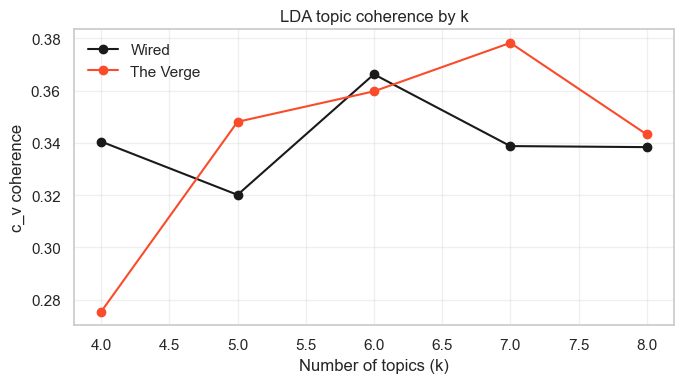

In [260]:
def coherence_for_k(
    docs,
    dictionary,
    corpus,
    k_values=(4, 5, 6, 7, 8),
    seed: int = 42
) -> dict[int, float]:
    scores: dict[int, float] = {}

    for k in k_values:
        if len(dictionary) == 0 or len(corpus) == 0:
            scores[k] = np.nan
            continue

        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=seed,
            passes=15,
            iterations=300,
            alpha="auto",
            eta="auto",
        )

        cm = CoherenceModel(
            model=lda,
            texts=docs,
            dictionary=dictionary,
            coherence="c_v"
        )

        scores[k] = cm.get_coherence()

    return scores

wired_coh = coherence_for_k(wired_docs, wired_dict, wired_corpus)
verge_coh = coherence_for_k(verge_docs, verge_dict, verge_corpus)

coh_df = pd.DataFrame({"Wired": wired_coh, "The Verge": verge_coh})
print(coh_df.round(3))

best_k = coh_df.idxmax()
best_score = coh_df.max()

print("\nBest k by brand:")
for brand in coh_df.columns:
    print(f"{brand}: k={best_k[brand]}, coherence={best_score[brand]:.3f}")

coh_df.to_csv(TAB_DIR / "12_lda_coherence_by_k.csv")

fig, ax = plt.subplots(figsize=(7, 4))

for brand in coh_df.columns:
    ax.plot(
        coh_df.index,
        pd.to_numeric(coh_df[brand], errors="coerce").to_numpy(dtype=float),
        marker="o",
        label=brand,
        color=BRAND_COLORS.get(brand, "grey")
    )

ax.set_xlabel("Number of topics (k)")
ax.set_ylabel("c_v coherence")
ax.set_title("LDA topic coherence by k")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "12_lda_coherence.png", dpi=150, bbox_inches="tight")
plt.show()

In [261]:
def fit_lda(corpus, dictionary, k, seed: int = 42):
    return LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=k,
        random_state=seed, passes=20, iterations=400, alpha="auto", eta="auto"
    )

# Chosen using coherence + interpretability: 5 topics kept for both brands to support a balanced comparison.
K_WIRED = 5
K_VERGE = 5
wired_lda = fit_lda(wired_corpus, wired_dict, K_WIRED)
verge_lda = fit_lda(verge_corpus, verge_dict, K_VERGE)

def topic_table(model, brand: str, topn: int = 12) -> pd.DataFrame:
    rows = []
    for tid in range(model.num_topics):
        terms = model.show_topic(tid, topn=topn)
        rows.append({
            "brand": brand,
            "topic_id": tid,
            "top_terms": ", ".join([t for t, _ in terms]),
            "term_weights": ", ".join([f"{w:.3f}" for _, w in terms]),
        })
    return pd.DataFrame(rows)

topics_df = pd.concat([
    topic_table(wired_lda, "Wired"),
    topic_table(verge_lda, "The Verge"),
], ignore_index=True)

print(topics_df.to_string(index=False))
topics_df.to_csv(TAB_DIR / "13_lda_topics.csv", index=False)

    brand  topic_id                                                                                     top_terms                                                                       term_weights
    Wired         0             report, code, magazine, data, social, new, story, company, medium, ice, doge, say 0.019, 0.013, 0.012, 0.011, 0.010, 0.009, 0.009, 0.009, 0.009, 0.008, 0.007, 0.007
    Wired         1          best, meta, data, new, report, magazine, phone, model, tested, security, story, tool 0.025, 0.019, 0.017, 0.016, 0.014, 0.013, 0.012, 0.010, 0.010, 0.010, 0.009, 0.008
    Wired         2  report, trump, musk, government, elon, openai, company, social, doge, iran, agent, anthropic 0.038, 0.022, 0.020, 0.014, 0.014, 0.014, 0.010, 0.009, 0.009, 0.009, 0.008, 0.008
    Wired         3            magazine, article, reporting, story, know, tech, read, look, new, say, apple, work 0.044, 0.023, 0.017, 0.014, 0.014, 0.013, 0.011, 0.010, 0.010, 0.008, 0.008, 0.008
    Wired      

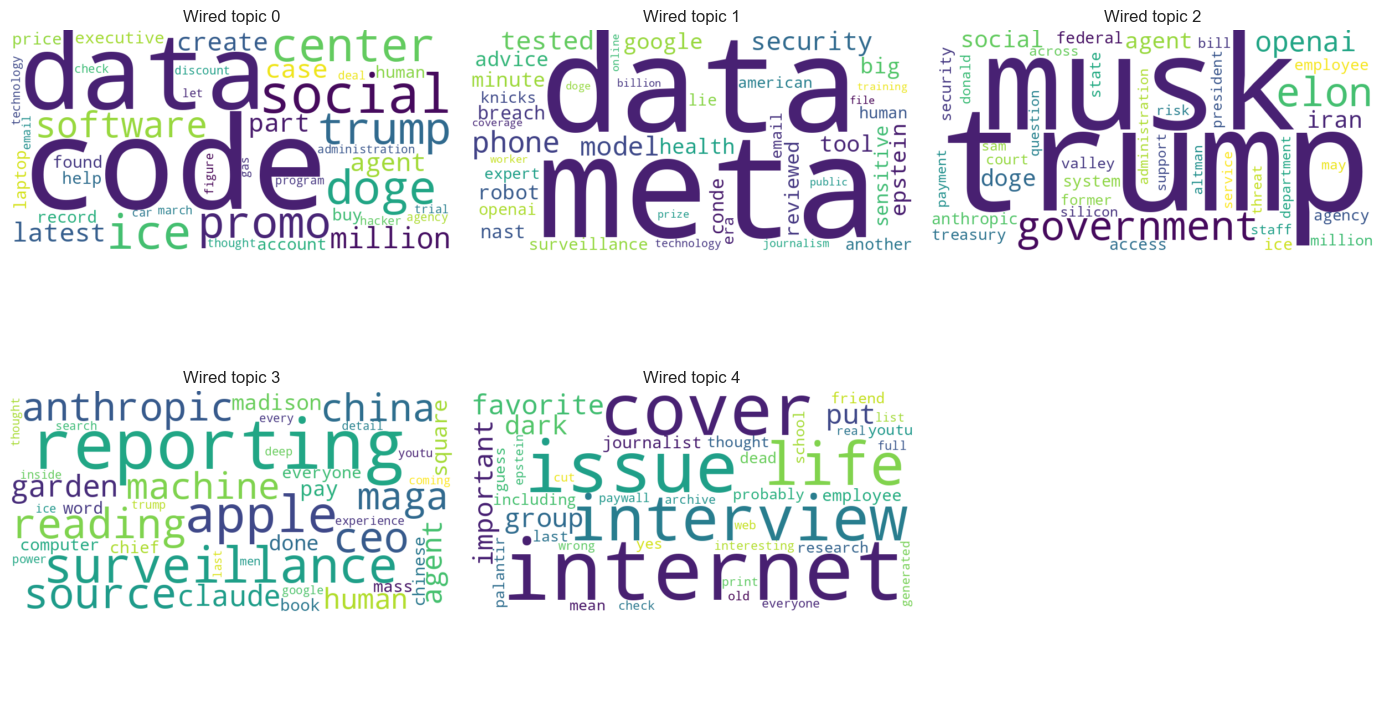

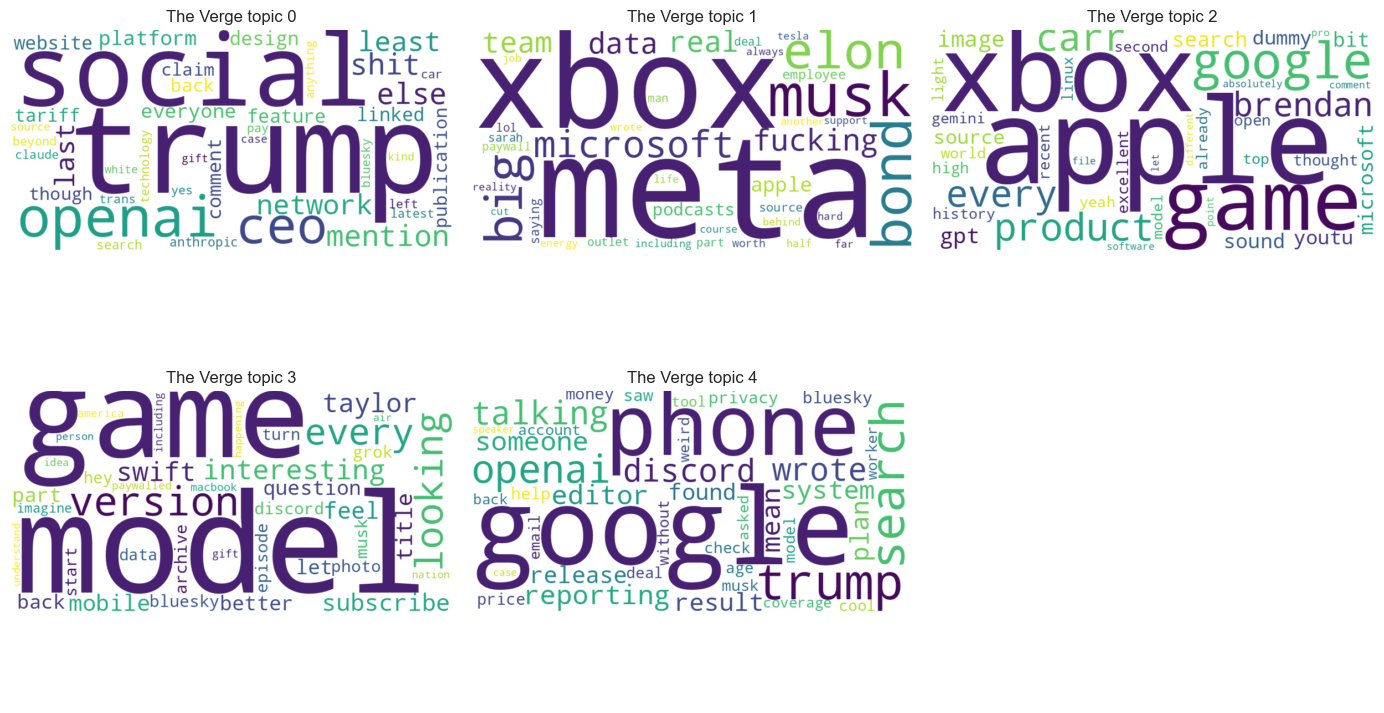

LDA topic terms:
       brand  topic                                          top_terms
0      Wired      0  code, data, social, ice, doge, center, trump, ...
1      Wired      1  meta, data, phone, model, tested, security, to...
2      Wired      2  trump, musk, government, elon, openai, social,...
3      Wired      3  reporting, apple, surveillance, source, ceo, r...
4      Wired      4  internet, cover, issue, interview, life, favor...
5  The Verge      0  trump, social, openai, ceo, mention, shit, els...
6  The Verge      1  meta, xbox, musk, bond, elon, big, microsoft, ...
7  The Verge      2  apple, xbox, game, google, product, carr, ever...
8  The Verge      3  model, game, version, looking, every, interest...
9  The Verge      4  google, phone, trump, search, openai, talking,...


In [262]:
# LDA topic word clouds

extra_topic_stopwords = {
    "article", "report", "magazine", "story", "read", "say", "new",
    "piece", "according", "link", "medium", "feed", "posted",
    "people", "time", "year", "week", "day", "month",
    "good", "best", "great", "first", "look", "need", "keep",
    "review", "work", "working", "company", "content",
    "subscriber", "subscription", "podcast", "headline",
    "wired", "verge",
    "know", "tech", "lot", "ago", "think", "news", "bad", "love", "next",
    "user", "right", "actually", "something", "anyone", "getting", "find",
    "might", "please", "thanks", "maybe", "pretty", "seems", "want",
    "make", "making", "made", "use", "using", "used", "live", "video",
    "show", "page", "site", "free", "hit", "line"
}


def plot_topic_clouds(lda_model, brand: str, fname: str) -> None:
    k = lda_model.num_topics
    cols = 3
    rows = int(np.ceil(k / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for topic_id in range(k):
        terms = lda_model.show_topic(topic_id, topn=100)

        freqs = {
            word: weight
            for word, weight in terms
            if word not in extra_topic_stopwords
        }

        wc = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap="viridis",
            max_words=40,
            prefer_horizontal=0.9,
            random_state=42
        )

        wc.generate_from_frequencies(freqs)

        axes[topic_id].imshow(wc, interpolation="bilinear")
        axes[topic_id].axis("off")
        axes[topic_id].set_title(f"{brand} topic {topic_id}")

    for ax in axes[k:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


def topic_terms_table(lda_model, brand: str, topn: int = 10) -> pd.DataFrame:
    rows = []

    for topic_id in range(lda_model.num_topics):
        terms = lda_model.show_topic(topic_id, topn=100)

        clean_terms = [
            term
            for term, weight in terms
            if term not in extra_topic_stopwords
        ][:topn]

        rows.append({
            "brand": brand,
            "topic": topic_id,
            "top_terms": ", ".join(clean_terms)
        })

    return pd.DataFrame(rows)


plot_topic_clouds(wired_lda, "Wired", "13_wired_topic_wordclouds.png")
plot_topic_clouds(verge_lda, "The Verge", "14_verge_topic_wordclouds.png")

topic_terms = pd.concat(
    [
        topic_terms_table(wired_lda, "Wired"),
        topic_terms_table(verge_lda, "The Verge")
    ],
    ignore_index=True
)

print("LDA topic terms:")
print(topic_terms)

topic_terms.to_csv(TAB_DIR / "13_lda_topic_terms.csv", index=False)

In [263]:
def assign_dominant_topic(lda_model, dictionary, df: pd.DataFrame) -> pd.DataFrame:
    topics = []

    for txt in df["text_clean_no_brand"]:
        if not txt:
            topics.append((-1, 0.0))
            continue

        bow = dictionary.doc2bow(str(txt).split())

        if not bow:
            topics.append((-1, 0.0))
            continue

        dist = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_id, prob = max(dist, key=lambda x: x[1])
        topics.append((topic_id, prob))

    out = df.copy()
    out["dominant_topic"] = [t[0] for t in topics]
    out["dominant_topic_prob"] = [t[1] for t in topics]

    return out


wired_topics = assign_dominant_topic(wired_lda, wired_dict, wired_posts)
verge_topics = assign_dominant_topic(verge_lda, verge_dict, verge_posts)

wired_topics.to_csv(PROC_DIR / "wired_posts_topics.csv", index=False)
verge_topics.to_csv(PROC_DIR / "verge_posts_topics.csv", index=False)

topic_posts = pd.concat(
    [
        wired_topics.assign(brand="Wired"),
        verge_topics.assign(brand="The Verge")
    ],
    ignore_index=True
)

topic_posts["vader_compound"] = pd.to_numeric(topic_posts["vader_compound"], errors="coerce").fillna(0)
topic_posts["like_count"] = pd.to_numeric(topic_posts["like_count"], errors="coerce").fillna(0)
topic_posts["repost_count"] = pd.to_numeric(topic_posts["repost_count"], errors="coerce").fillna(0)

topic_sent = (
    topic_posts[topic_posts["dominant_topic"] >= 0]
    .groupby(["brand", "dominant_topic"])
    .agg(
        n_posts=("uri", "count"),
        mean_topic_prob=("dominant_topic_prob", "mean"),
        mean_compound=("vader_compound", "mean"),
        median_compound=("vader_compound", "median"),
        mean_likes=("like_count", "mean"),
        median_likes=("like_count", "median"),
        mean_reposts=("repost_count", "mean"),
        median_reposts=("repost_count", "median"),
    )
    .round(3)
    .reset_index()
)

print(topic_sent.to_string(index=False))

topic_sent.to_csv(TAB_DIR / "14_topic_sentiment_engagement.csv", index=False)

    brand  dominant_topic  n_posts  mean_topic_prob  mean_compound  median_compound  mean_likes  median_likes  mean_reposts  median_reposts
The Verge               0      242            0.887          0.116            0.000       7.843           1.0         2.161             0.0
The Verge               1      237            0.874          0.128            0.052       8.464           1.0         1.709             0.0
The Verge               2      247            0.886          0.117            0.000       7.713           1.0         1.518             0.0
The Verge               3      204            0.894          0.213            0.226      10.961           1.0         1.691             0.0
The Verge               4      220            0.877          0.127            0.000      14.014           1.0         4.245             0.0
    Wired               0      290            0.847          0.091            0.000      22.793           0.0         8.803             0.0
    Wired           

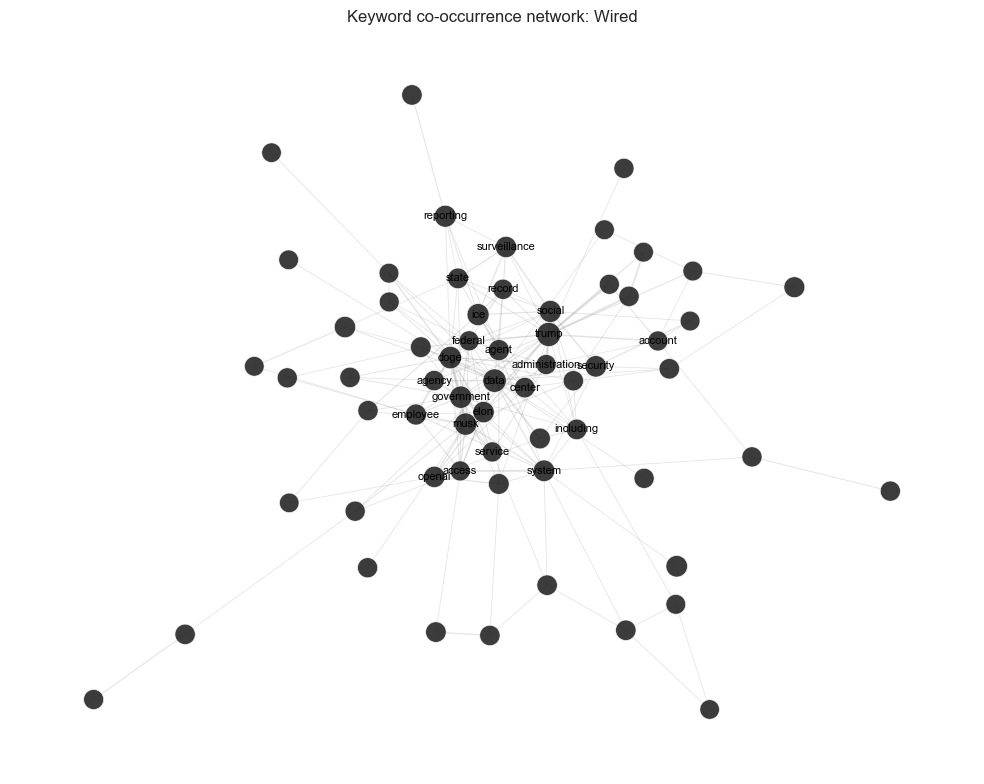

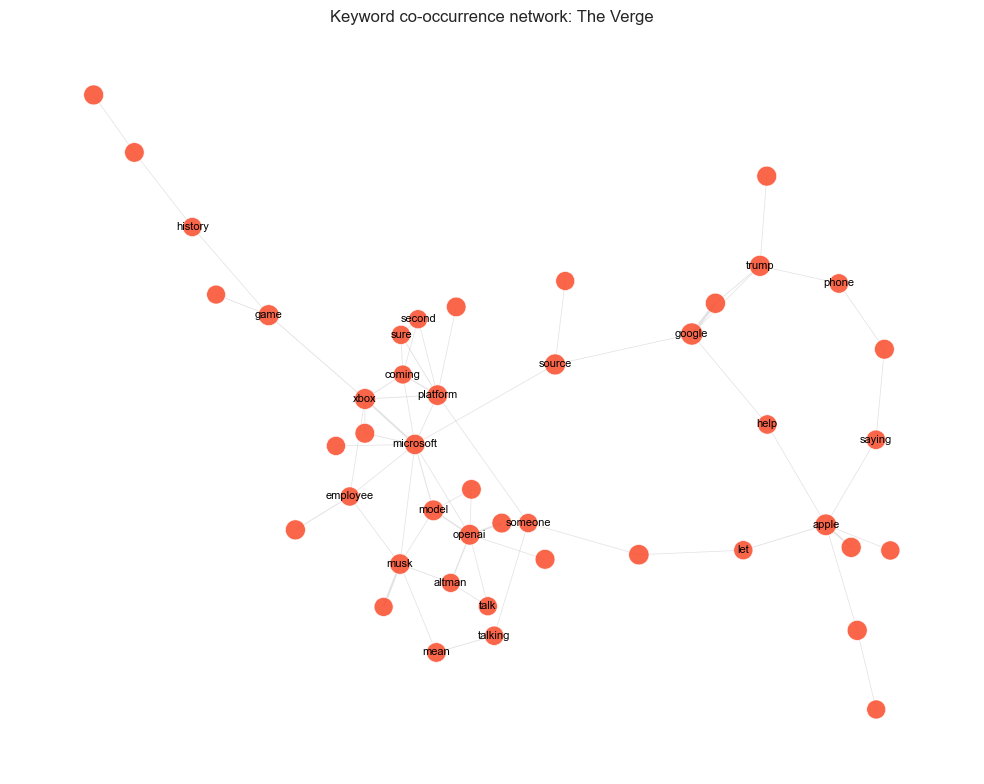

Saved topic/keyword outputs.


In [264]:
# Keyword co-occurrence network

network_stopwords = {
    "article", "report", "magazine", "story", "read", "say", "new",
    "piece", "according", "link", "medium", "feed", "posted",
    "people", "time", "year", "week", "day", "month",
    "good", "best", "great", "first", "look", "need", "keep",
    "review", "work", "working", "company", "content",
    "subscriber", "subscription", "podcast", "headline",
    "wired", "verge",
    "know", "tech", "lot", "ago", "think", "news", "bad", "love", "next",
    "user", "right", "actually", "something", "anyone", "getting", "find",
    "might", "please", "thanks", "maybe", "pretty", "seems", "want",
    "make", "making", "made", "use", "using", "used", "live", "video",
    "show", "page", "site", "free", "hit", "line"
}


def cooccurrence_graph(
    df: pd.DataFrame,
    top_vocab: int = 70,
    min_edge_weight: int = 3
) -> nx.Graph:
    token_counter = Counter()
    docs = []

    for txt in df["text_clean_no_brand"].fillna(""):
        toks = [
            t for t in str(txt).split()
            if t not in network_stopwords and len(t) > 2
        ]

        toks = list(dict.fromkeys(toks))
        docs.append(toks)
        token_counter.update(toks)

    vocab = set([t for t, _ in token_counter.most_common(top_vocab)])

    edge_counter = Counter()

    for toks in docs:
        toks = [t for t in toks if t in vocab]

        for a, b in combinations(sorted(set(toks)), 2):
            edge_counter[(a, b)] += 1

    G = nx.Graph()

    for token, count in token_counter.most_common(top_vocab):
        G.add_node(token, frequency=count)

    for (a, b), w in edge_counter.items():
        if w >= min_edge_weight:
            G.add_edge(a, b, weight=w)

    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)

    if G.number_of_nodes() > 0 and not nx.is_connected(G):
        largest_component = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_component).copy()

    return G


def plot_cooccurrence(G: nx.Graph, brand: str, fname: str) -> pd.DataFrame:
    if G.number_of_nodes() == 0:
        print(f"No graph for {brand}")
        return pd.DataFrame()

    centrality = nx.degree_centrality(G)

    node_df = pd.DataFrame({
        "token": list(G.nodes()),
        "frequency": [G.nodes[n].get("frequency", 0) for n in G.nodes()],
        "degree_centrality": [centrality.get(n, 0) for n in G.nodes()],
    }).sort_values("degree_centrality", ascending=False)

    pos = nx.spring_layout(
        G,
        seed=42,
        k=0.45,
        iterations=150,
        weight="weight"
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    node_sizes = [
        100 + 22 * np.sqrt(G.nodes[n].get("frequency", 0))
        for n in G.nodes()
    ]

    edge_widths = [
        0.25 + 0.10 * G.edges[e].get("weight", 1)
        for e in G.edges()
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_widths,
        alpha=0.22,
        edge_color="grey"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=BRAND_COLORS.get(brand, "grey"),
        alpha=0.85,
        linewidths=0.5,
        edgecolors="white"
    )

    labels = {n: n for n in node_df.head(25)["token"]}

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=8,
        font_color="black"
    )

    ax.set_title(f"Keyword co-occurrence network: {brand}")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

    return node_df


wired_G = cooccurrence_graph(wired_posts)
verge_G = cooccurrence_graph(verge_posts)

wired_node_df = plot_cooccurrence(
    wired_G,
    "Wired",
    "15_wired_keyword_network.png"
)

verge_node_df = plot_cooccurrence(
    verge_G,
    "The Verge",
    "15_verge_keyword_network.png"
)

wired_node_df.to_csv(TAB_DIR / "15_wired_keyword_network_nodes.csv", index=False)
verge_node_df.to_csv(TAB_DIR / "15_verge_keyword_network_nodes.csv", index=False)

topic_summary_json = {
    "top_keywords": kw_df.to_dict("records"),
    "lda_topics": topics_df.to_dict("records"),
    "topic_sentiment_engagement": topic_sent.to_dict("records"),
    "coherence_by_k": coh_df.reset_index(names="k").to_dict("records"),
    "method_notes": [
        "Topic modelling uses text_clean_no_brand so brand names do not dominate topics.",
        "Dictionary terms are filtered using no_below=5 and no_above=0.60.",
        "Keyword co-occurrence uses unique tokens per post and retains edges with at least three co-occurrences.",
        "Generic journalistic and platform-format terms are removed before network construction.",
        "Only the largest connected component is plotted to improve readability."
    ],
}

with open(PROC_DIR / "topic_keyword_summary.json", "w") as f:
    json.dump(topic_summary_json, f, indent=2, default=str)

print("Saved topic/keyword outputs.")

## 6. Network Analytics & Micro-Influencer Recommendation

In [265]:
# Network Analytics & Micro-Influencer Recommendation

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts    = pd.read_csv(PROC_DIR / "wired_posts_topics.csv", parse_dates=["created_at"])
verge_posts    = pd.read_csv(PROC_DIR / "verge_posts_topics.csv", parse_dates=["created_at"])
wired_profiles = pd.read_csv(PROC_DIR / "wired_profiles_clean.csv", parse_dates=["created_at"])
verge_profiles = pd.read_csv(PROC_DIR / "verge_profiles_clean.csv", parse_dates=["created_at"])

print(f"Loaded network inputs: Wired={len(wired_posts)}, Verge={len(verge_posts)}")

Loaded network inputs: Wired=1578, Verge=1153


In [266]:
MENTION_RE = re.compile(r"@([\w.-]+)")

def build_user_network(posts: pd.DataFrame, profiles: pd.DataFrame) -> nx.DiGraph:
    """
    Directed graph: edge from author -> mentioned/replied user handle.
    Mentions create explicit social ties; replies create stronger interaction ties
    when reply metadata is available.
    """
    handle_to_did = dict(zip(profiles["handle"].astype(str).str.lower(), profiles["did"]))
    G = nx.DiGraph()

    # Add known author nodes with attributes
    for _, p in profiles.iterrows():
        did = p["did"]
        G.add_node(
            did,
            handle=p.get("handle"),
            followers_count=p.get("followers_count", 0),
            display_name=p.get("display_name", ""),
            node_type="author"
        )

    for _, row in posts.iterrows():
        source = row["author_did"]
        if source not in G:
            G.add_node(source, handle=row.get("author_handle", source), node_type="author")

        # Mention edges from extracted mentions column
        mentions = []
        if isinstance(row.get("mentions"), str) and row.get("mentions"):
            mentions = [m.lstrip("@").lower() for m in row["mentions"].split(";") if m]
        else:
            mentions = [m.lower() for m in MENTION_RE.findall(str(row.get("text_raw", "")))]

        for handle in mentions:
            target = handle_to_did.get(handle, handle)
            if target == source:
                continue
            if not G.has_node(target):
                G.add_node(target, handle=handle, node_type="mentioned_only")
            if G.has_edge(source, target):
                G[source][target]["weight"] += 1
            else:
                G.add_edge(source, target, weight=1, relation="mention")

        # Replies: if a post is marked as reply, add weak self-contained signal
        # to preserve the higher interaction intent in scoring even without the target DID.
        if bool(row.get("is_reply")):
            target = f"reply_context::{row.get('author_did')}"
            # Do NOT add self-loop; instead mark a reply-context node to boost out-degree slightly
            if not G.has_node(target):
                G.add_node(target, handle="reply_context", node_type="reply_context")
            if G.has_edge(source, target):
                G[source][target]["weight"] += 2
            else:
                G.add_edge(source, target, weight=2, relation="reply_context")
    return G

wired_G = build_user_network(wired_posts, wired_profiles)
verge_G = build_user_network(verge_posts, verge_profiles)

print(f"Wired graph: nodes={wired_G.number_of_nodes()}, edges={wired_G.number_of_edges()}")
print(f"Verge graph: nodes={verge_G.number_of_nodes()}, edges={verge_G.number_of_edges()}")

Wired graph: nodes=2157, edges=972
Verge graph: nodes=2124, edges=1119


In [267]:
def centrality_table(G: nx.DiGraph) -> pd.DataFrame:
    in_deg  = dict(G.in_degree(weight="weight"))
    out_deg = dict(G.out_degree(weight="weight"))

    # Undirected projection is more stable for sparse directed mention networks.
    UG = G.to_undirected()

    if UG.number_of_edges() > 0:
        try:
            eig = nx.eigenvector_centrality(
                UG,
                weight="weight",
                max_iter=1000,
                tol=1e-06
            )
        except nx.PowerIterationFailedConvergence:
            print("[warn] Eigenvector centrality did not converge; using zeros.")
            eig = {n: 0 for n in G.nodes()}

        bet = nx.betweenness_centrality(
            UG,
            weight="weight",
            normalized=True
        )
    else:
        eig = {n: 0 for n in G.nodes()}
        bet = {n: 0 for n in G.nodes()}

    rows = []
    for n in G.nodes():
        rows.append({
            "author_did": n,
            "handle": G.nodes[n].get("handle"),
            "node_type": G.nodes[n].get("node_type"),
            "in_degree": in_deg.get(n, 0),
            "out_degree": out_deg.get(n, 0),
            "eigenvector": eig.get(n, 0),
            "betweenness": bet.get(n, 0),
        })

    return pd.DataFrame(rows)


wired_cent = centrality_table(wired_G)
verge_cent = centrality_table(verge_G)

wired_cent.to_csv(TAB_DIR / "11_wired_network_centrality.csv", index=False)
verge_cent.to_csv(TAB_DIR / "11_verge_network_centrality.csv", index=False)

print("Top Wired centrality:")
print(wired_cent.sort_values("eigenvector", ascending=False).head(10).to_string(index=False))

print("\nTop Verge centrality:")
print(verge_cent.sort_values("eigenvector", ascending=False).head(10).to_string(index=False))

Top Wired centrality:
                      author_did                       handle node_type  in_degree  out_degree  eigenvector  betweenness
did:plc:inz4fkbbp7ms3ixufw6xuvdi                    wired.com    author        424           0     0.697338     0.073983
did:plc:mvw7btcxe6jgznss25lcmus7 christinaayiotis.bsky.social    author          0          17     0.304093     0.000000
did:plc:dztnobglcuywvvft7ldnyy6f   semireflection.bsky.social    author          0          74     0.220687     0.007897
did:plc:5gdjq6qb6oratqtdfchsqbr4    noahshachtman.bsky.social    author          7          16     0.174086     0.005404
did:plc:eewrv6igoxnyqfo3ftj6tjc7       thiccreese.bsky.social    author          2          15     0.168844     0.000617
did:plc:37perdj2mub7q3wbyn7yylik      jeremywired.bsky.social    author          0          11     0.165440     0.000023
did:plc:2mhcf74vqcaa4hz36njfdtn5   katie-drummond.bsky.social    author          4          13     0.155481     0.001334
did:plc:34

In [268]:
def author_features(posts: pd.DataFrame, profiles: pd.DataFrame, cent: pd.DataFrame) -> pd.DataFrame:
    by_author = posts.groupby("author_did").agg(
        posts            = ("uri",            "count"),
        total_likes      = ("like_count",     "sum"),
        total_reposts    = ("repost_count",   "sum"),
        total_replies    = ("reply_count",    "sum"),
        mean_likes       = ("like_count",     "mean"),
        mean_reposts     = ("repost_count",   "mean"),
        mean_replies     = ("reply_count",    "mean"),
        mean_compound    = ("vader_compound", "mean"),
        pct_positive     = ("sentiment_label", lambda s: (s == "positive").mean() * 100),
        pct_negative     = ("sentiment_label", lambda s: (s == "negative").mean() * 100),
        reply_share      = ("is_reply",       "mean"),
        mean_topic_conf  = ("dominant_topic_prob", "mean"),
    ).reset_index()

    by_author["engagement_total"] = (
        by_author["total_likes"] + by_author["total_reposts"] + by_author["total_replies"]
    )
    by_author["engagement_per_post"] = by_author["engagement_total"] / by_author["posts"].clip(lower=1)

    out = by_author.merge(
        profiles[["did", "handle", "display_name", "description",
                  "followers_count", "follows_count", "posts_count", "created_at",
                  "follower_following_ratio"]],
        left_on="author_did", right_on="did", how="left"
    ).drop(columns="did")

    out = out.merge(
        cent[["author_did", "in_degree", "out_degree", "eigenvector", "betweenness"]],
        on="author_did", how="left"
    )
    return out

wired_authors = author_features(wired_posts, wired_profiles, wired_cent)
verge_authors = author_features(verge_posts, verge_profiles, verge_cent)

In [269]:
# Replace any NaN centrality (authors not connected in the mention graph) with 0.
for col in ["eigenvector", "in_degree", "out_degree", "betweenness"]:
    wired_authors[col] = wired_authors[col].fillna(0)
    verge_authors[col] = verge_authors[col].fillna(0)


# Normalisation helpers for transparent composite scoring.
def minmax(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").fillna(0)

    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)

    return (s - s.min()) / (s.max() - s.min())


def score_candidates(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Log-transform followers and engagement to avoid large accounts dominating.
    followers = pd.to_numeric(out["followers_count"], errors="coerce").fillna(0)
    engagement = pd.to_numeric(out["engagement_per_post"], errors="coerce").fillna(0)
    posts = pd.to_numeric(out["posts"], errors="coerce").fillna(0)

    out["followers_log"] = np.log1p(followers)
    out["engagement_log"] = np.log1p(engagement)

    # Composite score weights:
    # 35% engagement, 25% network centrality, 20% positive brand tone, 10% brand-post volume, 10% follower base.
    out["score_engagement"] = minmax(out["engagement_log"])
    out["score_network"] = minmax(out["eigenvector"])
    out["score_sentiment"] = minmax(out["mean_compound"].clip(lower=-0.2, upper=0.8))

    out["score_posts"] = minmax(
        pd.Series(np.log1p(posts), index=out.index)
    )

    out["score_followers"] = minmax(out["followers_log"])

    out["composite_score"] = (
        0.35 * out["score_engagement"] +
        0.25 * out["score_network"] +
        0.20 * out["score_sentiment"] +
        0.10 * out["score_posts"] +
        0.10 * out["score_followers"]
    )

    return out.sort_values("composite_score", ascending=False)


wired_scored = score_candidates(wired_authors)
verge_scored = score_candidates(verge_authors)

In [270]:
def centrality_table(G: nx.DiGraph) -> pd.DataFrame:
    in_deg = dict(G.in_degree(weight="weight"))
    out_deg = dict(G.out_degree(weight="weight"))

    # Undirected projection is more stable for sparse directed mention networks.
    UG = G.to_undirected()

    if UG.number_of_edges() > 0:
        try:
            eig = nx.eigenvector_centrality(
                UG,
                weight="weight",
                max_iter=1000,
                tol=1e-06
            )
        except nx.PowerIterationFailedConvergence:
            print("[warn] Eigenvector centrality did not converge; using zeros.")
            eig = {n: 0 for n in G.nodes()}

        bet = nx.betweenness_centrality(
            UG,
            weight="weight",
            normalized=True
        )
    else:
        eig = {n: 0 for n in G.nodes()}
        bet = {n: 0 for n in G.nodes()}

    rows = []

    for n in G.nodes():
        rows.append({
            "author_did": n,
            "handle": G.nodes[n].get("handle"),
            "node_type": G.nodes[n].get("node_type"),
            "in_degree": in_deg.get(n, 0),
            "out_degree": out_deg.get(n, 0),
            "eigenvector": eig.get(n, 0),
            "betweenness": bet.get(n, 0),
        })

    return pd.DataFrame(rows)


wired_cent = centrality_table(wired_G)
verge_cent = centrality_table(verge_G)

wired_cent.to_csv(TAB_DIR / "11_wired_network_centrality.csv", index=False)
verge_cent.to_csv(TAB_DIR / "11_verge_network_centrality.csv", index=False)

official_handles = {
    "wired.com",
    "theverge.com",
    "handle.invalid"
}

wired_cent_candidates = wired_cent[
    ~wired_cent["handle"].isin(official_handles)
].copy()

verge_cent_candidates = verge_cent[
    ~verge_cent["handle"].isin(official_handles)
].copy()

wired_cent_candidates = wired_cent_candidates[
    wired_cent_candidates["handle"].notna()
].copy()

verge_cent_candidates = verge_cent_candidates[
    verge_cent_candidates["handle"].notna()
].copy()

wired_cent_candidates.to_csv(
    TAB_DIR / "11_wired_network_centrality_candidates.csv",
    index=False
)

verge_cent_candidates.to_csv(
    TAB_DIR / "11_verge_network_centrality_candidates.csv",
    index=False
)

print("Top Wired centrality candidates:")
print(
    wired_cent_candidates
    .sort_values("eigenvector", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nTop Verge centrality candidates:")
print(
    verge_cent_candidates
    .sort_values("eigenvector", ascending=False)
    .head(10)
    .to_string(index=False)
)

Top Wired centrality candidates:
                      author_did                       handle node_type  in_degree  out_degree  eigenvector  betweenness
did:plc:mvw7btcxe6jgznss25lcmus7 christinaayiotis.bsky.social    author          0          17     0.304093     0.000000
did:plc:dztnobglcuywvvft7ldnyy6f   semireflection.bsky.social    author          0          74     0.220687     0.007897
did:plc:5gdjq6qb6oratqtdfchsqbr4    noahshachtman.bsky.social    author          7          16     0.174086     0.005404
did:plc:eewrv6igoxnyqfo3ftj6tjc7       thiccreese.bsky.social    author          2          15     0.168844     0.000617
did:plc:37perdj2mub7q3wbyn7yylik      jeremywired.bsky.social    author          0          11     0.165440     0.000023
did:plc:2mhcf74vqcaa4hz36njfdtn5   katie-drummond.bsky.social    author          4          13     0.155481     0.001334
did:plc:34isotrs7rzjd3czk44hnkxh                  surf.social    author          1          36     0.140420     0.003228

In [271]:
# Micro-influencer filter set:
#   - 1,000-100,000 followers (the standard "micro" band; rules out macro/mega).
#   - At least 2 brand-relevant posts (rules out one-off mentions).
#   - Mean compound polarity > 0 (positive-leaning toward the brand).
#   - Mean engagement_per_post >= 2 (rules out zero-engagement bots).
#   - Account age >= 90 days (rules out brand-new throwaway accounts).

NOW = pd.Timestamp.now().tz_localize(None)

# Word-boundary brand patterns (case-insensitive) for the editorial filter.
INSIDER_PATTERNS = {
    "Wired":     re.compile(r"\bwired\b|wired\.co|@wired",        re.IGNORECASE),
    "The Verge": re.compile(r"\bverge\b|theverge\.com|@theverge", re.IGNORECASE),
}


def apply_editorial_filter(df: pd.DataFrame, brand: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Drop accounts whose handle / display_name / description matches the brand pattern."""
    pat = INSIDER_PATTERNS[brand]
    out = df.copy()

    handle_str = out["handle"].fillna("").astype(str)

    display_str = (
        out["display_name"].fillna("").astype(str)
        if "display_name" in out.columns
        else pd.Series("", index=out.index)
    )

    bio_str = (
        out["description"].fillna("").astype(str)
        if "description" in out.columns
        else pd.Series("", index=out.index)
    )

    is_insider = (
        handle_str.str.contains(pat, regex=True, na=False) |
        display_str.str.contains(pat, regex=True, na=False) |
        bio_str.str.contains(pat, regex=True, na=False)
    )

    excluded_cols = [
        c for c in ["handle", "display_name", "description"]
        if c in out.columns
    ]

    excluded = out.loc[is_insider, excluded_cols].copy()

    return out.loc[~is_insider].reset_index(drop=True), excluded


def apply_micro_filter(authors: pd.DataFrame, brand: str) -> pd.DataFrame:
    df = authors.copy()

    df["followers_count"] = pd.to_numeric(df["followers_count"], errors="coerce").fillna(0)
    df["posts"] = pd.to_numeric(df["posts"], errors="coerce").fillna(0)
    df["mean_compound"] = pd.to_numeric(df["mean_compound"], errors="coerce").fillna(0)
    df["engagement_per_post"] = pd.to_numeric(df["engagement_per_post"], errors="coerce").fillna(0)
    df["composite_score"] = pd.to_numeric(df["composite_score"], errors="coerce").fillna(0)

    df["account_age_days"] = (
        NOW - pd.to_datetime(df["created_at"], errors="coerce", utc=True)
        .dt.tz_convert(None)
    ).dt.days

    mask = (
        df["followers_count"].between(1_000, 100_000) &
        (df["posts"] >= 2) &
        (df["mean_compound"] > 0) &
        (df["engagement_per_post"] >= 2) &
        (df["account_age_days"].fillna(0) >= 90)
    )

    df = df[mask].copy()

    df, excluded = apply_editorial_filter(df, brand)

    print(f"[{brand}] Editorial filter excluded {len(excluded)} insider/affiliated accounts.")

    if not excluded.empty:
        print("Sample excluded:")
        for _, r in excluded.head(5).iterrows():
            handle = str(r.get("handle", ""))
            display = str(r.get("display_name", ""))[:30]
            print(f"  - @{handle:30s} | {display}")

    return df.sort_values("composite_score", ascending=False).reset_index(drop=True)


wired_candidates = apply_micro_filter(wired_scored, "Wired")
verge_candidates = apply_micro_filter(verge_scored, "The Verge")

wired_candidates.to_csv(TAB_DIR / "12_wired_micro_influencer_scores.csv", index=False)
verge_candidates.to_csv(TAB_DIR / "12_verge_micro_influencer_scores.csv", index=False)

candidate_cols = [
    "handle",
    "display_name",
    "followers_count",
    "posts",
    "engagement_per_post",
    "mean_compound",
    "pct_positive",
    "eigenvector",
    "composite_score",
]

candidate_cols = [
    c for c in candidate_cols
    if c in wired_candidates.columns and c in verge_candidates.columns
]

print("\n=== Wired top micro-influencer candidates ===")
print(
    wired_candidates[candidate_cols]
    .head(5)
    .round(3)
    .to_string(index=False)
)

print("\n=== The Verge top micro-influencer candidates ===")
print(
    verge_candidates[candidate_cols]
    .head(5)
    .round(3)
    .to_string(index=False)
)

print("\nFinal recommended Wired candidate:")
print(
    wired_candidates[candidate_cols]
    .head(1)
    .round(3)
    .to_string(index=False)
)

print("\nFinal recommended The Verge candidate:")
print(
    verge_candidates[candidate_cols]
    .head(1)
    .round(3)
    .to_string(index=False)
)

[Wired] Editorial filter excluded 8 insider/affiliated accounts.
Sample excluded:
  - @katie-drummond.bsky.social     | Katie Drummond
  - @leahfeiger.bsky.social         | Leah Feiger
  - @emilymullin.bsky.social        | Emily Mullin
  - @telliotter.bsky.social         | Vittoria Elliott
  - @timmarchman.bsky.social        | Tim Marchman
[The Verge] Editorial filter excluded 6 insider/affiliated accounts.
Sample excluded:
  - @tinanguyen.bsky.social         | Tina Nguyen
  - @miasato.bsky.social            | Mia Sato
  - @superantonio64.bsky.social     | Antonio G. Di Benedetto
  - @lewisgordon.bsky.social        | Lewis Gordon
  - @kristenradtke.bsky.social      | Kristen Radtke

=== Wired top micro-influencer candidates ===
                   handle                    display_name  followers_count  posts  engagement_per_post  mean_compound  pct_positive  eigenvector  composite_score
   thiccreese.bsky.social                           Reece            18267      8               58.1

In [272]:
def show_candidate_posts(posts: pd.DataFrame, profiles: pd.DataFrame,
                         did: str, handle: str, n: int = 5) -> None:
    print(f"\n--- {handle} - top {n} most-engaged posts ---")
    cols = ["created_at", "like_count", "repost_count", "reply_count", "vader_compound", "text_raw"]
    tmp = posts[posts["author_did"] == did].copy()
    if tmp.empty:
        print("No posts found")
        return
    tmp["engagement"] = tmp["like_count"] + tmp["repost_count"] + tmp["reply_count"]
    print(tmp.sort_values("engagement", ascending=False)[cols].head(n).to_string(index=False, max_colwidth=220))

if not wired_candidates.empty:
    top = wired_candidates.iloc[0]
    show_candidate_posts(wired_posts, wired_profiles, top["author_did"], top["handle"])

if not verge_candidates.empty:
    top = verge_candidates.iloc[0]
    show_candidate_posts(verge_posts, verge_profiles, top["author_did"], top["handle"])


--- thiccreese.bsky.social - top 5 most-engaged posts ---
                      created_at  like_count  repost_count  reply_count  vader_compound                                                                                                                                                                                                                     text_raw
2026-04-28 11:51:51.311000+00:00         122            28            4         -0.2960 NEW: The DIY gadget is, in part, a rejection of our current moment, dominated by the predictable flatness of generative AI and minimalist, mass-produced devices.\n\nCheck out my news feature about cyberdecks for @wire...
2026-04-10 12:24:11.087000+00:00          96            25            2          0.5267                      NEW: Medical experts I spoke with balked at the idea of uploading their own health data for an AI model, like Meta’s Muse Spark, to analyze.\n\nLatest for @wired.com:\n\nwww.wired.com/story/metas-...
2026-04-07 22:

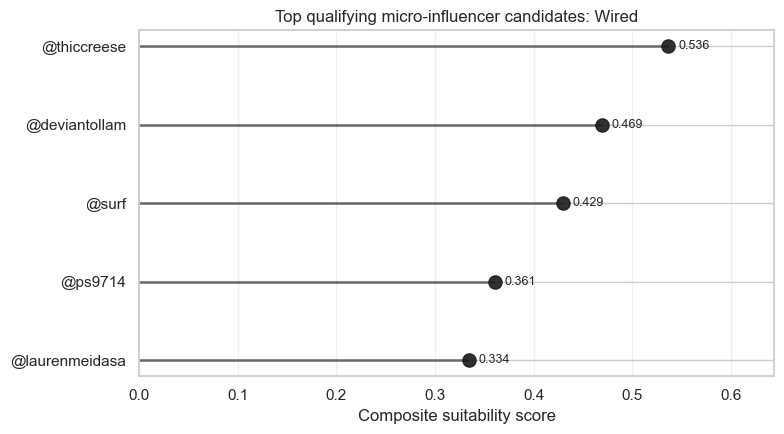

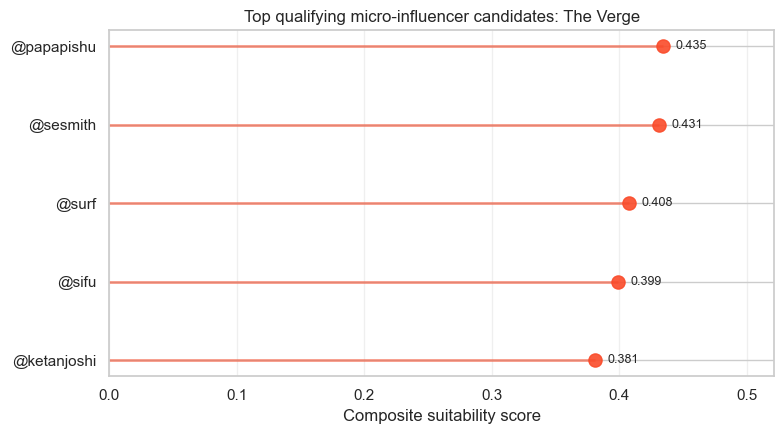

In [273]:
def plot_top_candidates(scored: pd.DataFrame, brand: str, fname: str, top_n: int = 5) -> None:
    if scored.empty:
        print(f"No qualifying candidates for {brand}")
        return

    top = scored.head(top_n).copy().sort_values("composite_score", ascending=True)
    top["composite_score"] = pd.to_numeric(top["composite_score"], errors="coerce").fillna(0)

    labels = ["@" + str(h).split(".")[0] for h in top["handle"]]
    scores = top["composite_score"].to_numpy(dtype=float)
    y = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.hlines(
        y=y,
        xmin=0,
        xmax=scores,
        color=BRAND_COLORS.get(brand, "grey"),
        alpha=0.55,
        linewidth=2
    )

    ax.scatter(
        scores,
        y,
        s=90,
        color=BRAND_COLORS.get(brand, "grey"),
        alpha=0.9,
        zorder=3
    )

    for i, score in enumerate(scores):
        ax.text(
            score + 0.01,
            y[i],
            f"{score:.3f}",
            va="center",
            fontsize=9
        )

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Composite suitability score")
    ax.set_title(f"Top qualifying micro-influencer candidates: {brand}")
    ax.set_xlim(0, max(0.05, float(scores.max()) * 1.20))
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


plot_top_candidates(wired_candidates, "Wired", "16_wired_micro_candidates.png")
plot_top_candidates(verge_candidates, "The Verge", "16_verge_micro_candidates.png")

In [274]:
def make_recommendation(scored: pd.DataFrame, brand: str) -> dict:
    if scored.empty:
        return {"brand": brand, "recommendation": None, "reason": "No candidates passed the filter set."}
    c = scored.iloc[0]
    return {
        "brand": brand,
        "recommended_handle": c["handle"],
        "display_name": c.get("display_name"),
        "author_did": c["author_did"],
        "followers_count": int(c["followers_count"]),
        "brand_posts": int(c["posts"]),
        "engagement_per_post": round(float(c["engagement_per_post"]), 3),
        "mean_compound_polarity": round(float(c["mean_compound"]), 3),
        "pct_positive_posts": round(float(c["pct_positive"]), 2),
        "eigenvector_centrality": round(float(c["eigenvector"]), 6),
        "composite_score": round(float(c["composite_score"]), 4),
        "reason": (
            "Selected as the highest-scoring qualifying micro-influencer after filtering for "
            "micro-scale reach, repeated brand relevance, positive sentiment, engagement per post, "
            "account age, and network centrality."
        )
    }

recommendations = {
    "wired": make_recommendation(wired_candidates, "Wired"),
    "verge": make_recommendation(verge_candidates, "The Verge"),
    "filter_criteria": {
        "followers_count": "1,000 to 100,000",
        "minimum_brand_posts": 2,
        "mean_compound_polarity": "> 0",
        "minimum_engagement_per_post": 2,
        "minimum_account_age_days": 90,
    },
    "score_weights": {
        "engagement_per_post_log": 0.35,
        "eigenvector_centrality": 0.25,
        "mean_brand_sentiment": 0.20,
        "brand_post_volume_log": 0.10,
        "followers_log": 0.10,
    },
    "method_notes": [
        "Network constructed from explicit @mentions plus reply-context ties; reply posts weighted double as they signal endorsement-with-amplification.",
        "Eigenvector centrality used over degree centrality because it captures connection to other influential users, not just raw mention count.",
        "Sentiment uses VADER mean compound from Phase 5 - measures sentiment of the user's posts about the brand, not arbitrary topics.",
    ],
}

with open(PROC_DIR / "influencer_recommendations.json", "w") as f:
    json.dump(recommendations, f, indent=2, default=str)

print("\n=== FINAL RECOMMENDATIONS ===\n")
for brand_key in ("wired", "verge"):
    rec = recommendations[brand_key]
    if rec.get("recommended_handle") is None:
        print(f"{rec['brand']}: NO QUALIFYING CANDIDATE - {rec['reason']}\n")
        continue
    print(f"{rec['brand']}:")
    print(f"  Handle             : @{rec['recommended_handle']}")
    print(f"  Display name       : {rec['display_name']}")
    print(f"  Followers          : {rec['followers_count']:,}")
    print(f"  Brand posts        : {rec['brand_posts']}")
    print(f"  Engagement/post    : {rec['engagement_per_post']}")
    print(f"  Mean polarity      : {rec['mean_compound_polarity']:+.3f}  ({rec['pct_positive_posts']}% positive)")
    print(f"  Eigenvector cent.  : {rec['eigenvector_centrality']}")
    print(f"  Composite score    : {rec['composite_score']}\n")

print(f"Saved -> {PROC_DIR / 'influencer_recommendations.json'}")


=== FINAL RECOMMENDATIONS ===

Wired:
  Handle             : @thiccreese.bsky.social
  Display name       : Reece
  Followers          : 18,267
  Brand posts        : 8
  Engagement/post    : 58.125
  Mean polarity      : +0.514  (87.5% positive)
  Eigenvector cent.  : 0.168844
  Composite score    : 0.5365

The Verge:
  Handle             : @papapishu.bsky.social
  Display name       : Chris Person
  Followers          : 30,473
  Brand posts        : 3
  Engagement/post    : 214.0
  Mean polarity      : +0.144  (33.33% positive)
  Eigenvector cent.  : 0.0
  Composite score    : 0.4345

Saved -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/processed/influencer_recommendations.json


## 7. Perceptual Map

In [275]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts  = pd.read_csv(PROC_DIR / "wired_posts_topics.csv")
verge_posts  = pd.read_csv(PROC_DIR / "verge_posts_topics.csv")
wired_scored = pd.read_csv(TAB_DIR / "12_wired_micro_influencer_scores.csv")
verge_scored = pd.read_csv(TAB_DIR / "12_verge_micro_influencer_scores.csv")

# --- Derive axis tokens from the LDA topics fitted in Phase 5 ---
# Methodology:
#   1. Load the per-brand LDA topic top-term lists from 13_lda_topics.csv.
#   2. Use a small seed lexicon to identify which topic id per brand is the
#      "politics & power" theme and which is the "consumer technology" theme.
#      The seed is used only to select topic ids; the axis vocabulary itself
#      is taken directly from the LDA top-term lists.
#   3. Union politics tokens across both brands and tech tokens across both
#      brands, then remove any overlap to keep the axes orthogonal.
#
# This grounds the perceptual axes in observed corpus structure rather than
# hand-curated vocabulary.

lda_topics = pd.read_csv(TAB_DIR / "13_lda_topics.csv")

POLITICS_SEED = {"trump", "musk", "elon", "doge", "government", "agency",
                 "biden", "white", "house", "thiel", "treasury", "ice"}
TECH_SEED     = {"apple", "google", "phone", "iphone", "android", "review",
                 "openai", "xbox", "meta", "model", "microsoft", "linux"}

def _topic_terms(row) -> set[str]:
    return {t.strip() for t in str(row["top_terms"]).split(",")}

def _select_topic(brand: str, seed: set[str]) -> int:
    """Return the topic_id whose top terms have the largest seed overlap."""
    sub = lda_topics[lda_topics["brand"] == brand]
    best_id, best_score = int(sub["topic_id"].iloc[0]), -1
    for _, row in sub.iterrows():
        score = len(_topic_terms(row) & seed)
        if score > best_score:
            best_score = score
            best_id = int(row["topic_id"])
    return best_id

def _terms_for(brand: str, topic_id: int) -> set[str]:
    sub = lda_topics[(lda_topics["brand"] == brand) &
                     (lda_topics["topic_id"] == topic_id)]
    return _topic_terms(sub.iloc[0]) if not sub.empty else set()

w_pol_id = _select_topic("Wired",     POLITICS_SEED)
w_tec_id = _select_topic("Wired",     TECH_SEED)
v_pol_id = _select_topic("The Verge", POLITICS_SEED)
v_tec_id = _select_topic("The Verge", TECH_SEED)

POLITICS_TOKENS = (_terms_for("Wired", w_pol_id)
                   | _terms_for("The Verge", v_pol_id))
TECH_TOKENS     = (_terms_for("Wired", w_tec_id)
                   | _terms_for("The Verge", v_tec_id))

overlap = POLITICS_TOKENS & TECH_TOKENS
POLITICS_TOKENS -= overlap
TECH_TOKENS     -= overlap

print(f"Selected politics topics: Wired=T{w_pol_id}, Verge=T{v_pol_id}")
print(f"Selected tech topics    : Wired=T{w_tec_id}, Verge=T{v_tec_id}")
print(f"Politics tokens (n={len(POLITICS_TOKENS)}): {sorted(POLITICS_TOKENS)}")
print(f"Tech tokens     (n={len(TECH_TOKENS)}):     {sorted(TECH_TOKENS)}")
print(f"Removed overlap (n={len(overlap)}):       {sorted(overlap)}")


# --- (rest of Phase 8 unchanged) ---
def discourse_index(text_series: pd.Series) -> float:
    """Mean per-post (tech_share - politics_share). +1 = pure tech, -1 = pure politics."""
    scores = []
    for txt in text_series.fillna("").astype(str):
        toks = txt.split()
        if not toks:
            continue
        n = len(toks)
        pol = sum(1 for t in toks if t in POLITICS_TOKENS) / n
        tec = sum(1 for t in toks if t in TECH_TOKENS) / n
        scores.append(tec - pol)
    return float(np.mean(scores)) if scores else 0.0

def author_discourse_index(posts: pd.DataFrame, author_did: str) -> float:
    return discourse_index(posts[posts["author_did"] == author_did]["text_clean_no_brand"])

# Brand-level coordinates
brand_points = []
for brand, posts in [("Wired", wired_posts), ("The Verge", verge_posts)]:
    brand_points.append({
        "brand":          brand,
        "x_discourse":    discourse_index(posts["text_clean_no_brand"]),
        "y_polarity":     float(posts["vader_compound"].mean()),
        "size_engagement": float(posts["like_count"].mean()),
        "n_posts":        len(posts),
    })
brand_df = pd.DataFrame(brand_points)
print("\nBrand coordinates:")
print(brand_df.to_string(index=False))

# Top-10 micro-influencer coordinates
def influencer_points(scored: pd.DataFrame, posts: pd.DataFrame,
                      brand: str, top_n: int = 10) -> pd.DataFrame:
    rows = []
    for _, c in scored.head(top_n).iterrows():
        rows.append({
            "brand":           brand,
            "handle":          c["handle"],
            "x_discourse":     author_discourse_index(posts, c["author_did"]),
            "y_polarity":      float(c["mean_compound"]),
            "size_engagement": float(c["mean_likes"]),
            "composite":       float(c["composite_score"]),
        })
    return pd.DataFrame(rows)

inf_df = pd.concat([
    influencer_points(wired_scored, wired_posts, "Wired"),
    influencer_points(verge_scored, verge_posts, "The Verge"),
], ignore_index=True)

print("\nInfluencer coordinates (top 10 per brand):")
print(inf_df.to_string(index=False))

Selected politics topics: Wired=T2, Verge=T0
Selected tech topics    : Wired=T1, Verge=T2
Politics tokens (n=17): ['agent', 'anthropic', 'company', 'doge', 'elon', 'feed', 'government', 'iran', 'know', 'link', 'medium', 'musk', 'openai', 'show', 'social', 'tech', 'trump']
Tech tokens     (n=19):     ['apple', 'best', 'data', 'game', 'google', 'magazine', 'meta', 'model', 'new', 'next', 'phone', 'read', 'review', 'security', 'story', 'tested', 'time', 'tool', 'xbox']
Removed overlap (n=3):       ['article', 'people', 'report']

Brand coordinates:
    brand  x_discourse  y_polarity  size_engagement  n_posts
    Wired     0.034060    0.078381        23.113435     1578
The Verge     0.017658    0.137024         9.658283     1153

Influencer coordinates (top 10 per brand):
    brand                    handle  x_discourse  y_polarity  size_engagement  composite
    Wired    thiccreese.bsky.social     0.074560    0.513537        44.750000   0.536484
    Wired  deviantollam.bsky.social     0.1

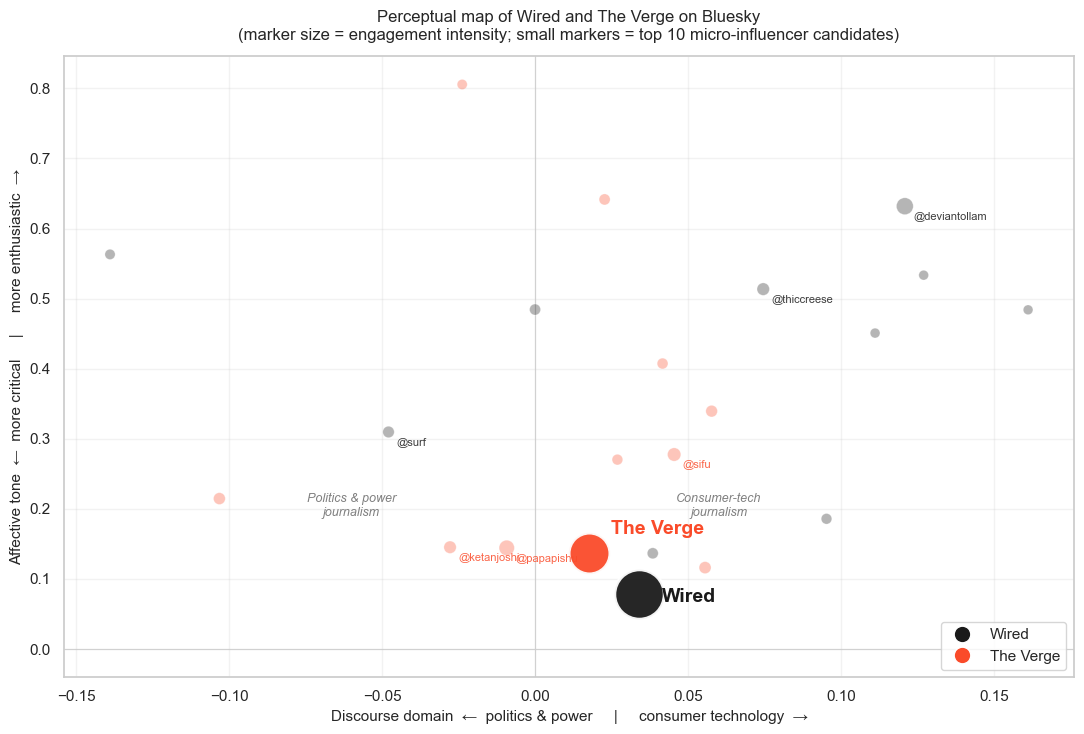

In [276]:
fig, ax = plt.subplots(figsize=(11, 7.5))

# Light reference lines
ax.axhline(0, color="lightgrey", lw=0.8, zorder=0)
ax.axvline(0, color="lightgrey", lw=0.8, zorder=0)

# Influencer markers
for brand, g in inf_df.groupby("brand"):
    brand_name = str(brand)

    sizes = 40 + 6 * np.sqrt(
        pd.to_numeric(g["size_engagement"], errors="coerce")
        .fillna(0)
        .clip(lower=0)
        .to_numpy(dtype=float)
    )

    ax.scatter(
        pd.to_numeric(g["x_discourse"], errors="coerce").to_numpy(dtype=float),
        pd.to_numeric(g["y_polarity"], errors="coerce").to_numpy(dtype=float),
        s=sizes,
        color=BRAND_COLORS.get(brand_name, "grey"),
        alpha=0.32,
        edgecolor="white",
        linewidth=0.5,
        zorder=2
    )

# Brand anchors
for _, row in brand_df.iterrows():
    brand_name = str(row["brand"])

    x_val = float(row["x_discourse"])
    y_val = float(row["y_polarity"])
    size_val = float(row["size_engagement"])

    ax.scatter(
        x_val,
        y_val,
        s=600 + 30 * size_val,
        color=BRAND_COLORS.get(brand_name, "grey"),
        alpha=0.95,
        edgecolor="white",
        linewidth=2.5,
        zorder=4
    )

    label_offset = (16, 14) if brand_name == "The Verge" else (16, -6)

    ax.annotate(
        brand_name,
        xy=(x_val, y_val),
        xytext=label_offset,
        textcoords="offset points",
        fontsize=14,
        fontweight="bold",
        color=BRAND_COLORS.get(brand_name, "grey"),
        zorder=5
    )

# Label the top-3 influencers per brand
top_label_df = (
    inf_df
    .assign(
        label_score=lambda d: pd.to_numeric(
            d["size_engagement"],
            errors="coerce"
        ).fillna(0)
    )
    .sort_values(["brand", "label_score"], ascending=[True, False])
    .groupby("brand")
    .head(3)
)

for _, row in top_label_df.iterrows():
    brand_name = str(row["brand"])
    handle = str(row["handle"])

    ax.annotate(
        f"@{handle.split('.')[0]}",
        xy=(float(row["x_discourse"]), float(row["y_polarity"])),
        xytext=(6, -10),
        textcoords="offset points",
        fontsize=8,
        color=BRAND_COLORS.get(brand_name, "grey"),
        alpha=0.85,
        zorder=5
    )

# Quadrant captions
ax.text(
    -0.06,
    0.19,
    "Politics & power\njournalism",
    fontsize=9,
    color="grey",
    ha="center",
    style="italic"
)

ax.text(
    0.06,
    0.19,
    "Consumer-tech\njournalism",
    fontsize=9,
    color="grey",
    ha="center",
    style="italic"
)

ax.set_xlabel(
    "Discourse domain  ←  politics & power     |     consumer technology  →",
    fontsize=11
)

ax.set_ylabel(
    "Affective tone  ←  more critical     |     more enthusiastic  →",
    fontsize=11
)

ax.set_title(
    "Perceptual map of Wired and The Verge on Bluesky\n"
    "(marker size = engagement intensity; small markers = top 10 micro-influencer candidates)",
    fontsize=12,
    pad=12
)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Wired",
        markerfacecolor=BRAND_COLORS.get("Wired", "grey"),
        markersize=12
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="The Verge",
        markerfacecolor=BRAND_COLORS.get("The Verge", "grey"),
        markersize=12
    ),
]

ax.legend(handles=legend_elements, loc="lower right", frameon=True)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / "16_perceptual_map.png", dpi=180, bbox_inches="tight")
plt.show()

In [277]:
perceptual_data = {
    "axes": {
        "x_definition": ("Discourse-domain index = mean per-post (tech_token_share - politics_token_share). "
                         "Negative -> politics & power; positive -> consumer technology."),
        "y_definition": "Affective tone = mean VADER compound polarity per brand.",
        "size_definition": "Engagement intensity = mean likes per post.",
    },
    "axis_token_sets": {
    "politics_power":      sorted(POLITICS_TOKENS),
    "consumer_technology": sorted(TECH_TOKENS),
    "derivation":          ("Tokens taken directly from the top-12 terms of "
                            f"Wired LDA topic {w_pol_id} / {w_tec_id} and "
                            f"Verge LDA topic {v_pol_id} / {v_tec_id}, "
                            "selected by overlap with seed lexicons. "
                            "Overlapping tokens removed for orthogonality."),
},
    "brand_points":      brand_df.to_dict("records"),
    "influencer_points": inf_df.to_dict("records"),
    "interpretation": [
        "Wired sits in the lower-left quadrant: politics-and-power journalism with a critical, slightly negative tone, but with high engagement intensity driven by a viral right-tail of political reporting (e.g. DOGE, Trump-Musk coverage).",
        "The Verge sits in the upper-right quadrant: consumer-technology journalism with a positive tone driven by product reviews and feature coverage (Apple, Google, Xbox, openAI), with steadier but lower per-post engagement.",
        "The two brands occupy genuinely distinct positions on the map the X-axis separation is large and based directly on observed vocabulary; the Y-axis separation is smaller but consistent across topic, post-type, and sentiment cuts.",
        "Influencer candidates cluster tightly around each brand's anchor, validating that the recommended micro-influencers reflect the brand's discourse position rather than sitting in the opposite quadrant.",
    ],
}
with open(PROC_DIR / "perceptual_map_data.json", "w") as f:
    json.dump(perceptual_data, f, indent=2, default=str)

print("Saved data/processed/perceptual_map_data.json")

Saved data/processed/perceptual_map_data.json


In [278]:
# Figure manifest guarantees Figure-N labels in the write-up are stable across re-runs and ordered consistently with notebook execution.

import os

FIGURE_FILES = sorted(
    list(FIG_DIR.glob("*.png")) + list(FIG_DIR.glob("*.pdf")),
    key=lambda p: p.name,
)

manifest = pd.DataFrame({
    "fig_id":    [f"Figure {i+1}" for i in range(len(FIGURE_FILES))],
    "filename":  [p.name for p in FIGURE_FILES],
    "path":      [os.path.relpath(p, PROJECT_ROOT) for p in FIGURE_FILES],
    "size_kb":   [round(p.stat().st_size / 1024, 1) for p in FIGURE_FILES],
    "modified":  [pd.Timestamp(p.stat().st_mtime, unit="s").strftime("%Y-%m-%d %H:%M")
                  for p in FIGURE_FILES],
})

manifest.to_csv(TAB_DIR / "00_figure_index.csv", index=False)

print(f"Saved figure index with {len(manifest)} figures -> "
      f"{TAB_DIR / '00_figure_index.csv'}")
print()
print(manifest.to_string(index=False))

Saved figure index with 49 figures -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/outputs/tables/00_figure_index.csv

   fig_id                           filename                                               path  size_kb         modified
 Figure 1               02_weekly_volume.png               outputs/figures/02_weekly_volume.png     72.1 2026-04-30 12:06
 Figure 2         03_engagement_boxplots.png         outputs/figures/03_engagement_boxplots.png     57.4 2026-04-30 07:55
 Figure 3     03_engagement_by_post_type.png     outputs/figures/03_engagement_by_post_type.png     38.5 2026-04-30 07:55
 Figure 4 03_engagement_distribution_log.png outputs/figures/03_engagement_distribution_log.png     76.0 2026-04-30 12:06
 Figure 5    03_engagement_distributions.png    outputs/figures/03_engagement_distributions.png     46.4 2026-04-30 02:17
 Figure 6      03_engagement_mean_median.png      outputs/figures/03_engagement_mean_medi